# SerafinoSignal
## Restaurant Complaint Theme Discovery Across Restaurants in Turkey

**Student:** Tawshif Al Mehrab  
**Course:** IAT 461  
**Term:** Summer 2026

---

## **1. Project Overview**

This project examines restaurant reviews from a hypothetical Turkish restaurant review website. The Director of Marketing and Outreach is the stakeholder, and instead of depending solely on unfiltered reviews and star ratings, he wants to know the recurrent causes of customer dissatisfaction.
The main question is:

**What complaint themes appear across restaurant reviews and which themes recur across multiple restaurants rather than being specific to one restaurant?**

Due to the lack of predefined complaint theme labels in the dataset, the project employs unsupervised text analysis. Finding significant and useful complaint patterns in the review text is the aim.

AI Usage declaration
- Purpose: This notebook uses Perplixity AI to assist with coding specific cells, generate tables ,ideas, polsihing brainstorm approaches and enhance results.
All AI-proposed code is reviewed and edited by me before execution. Anything committed as final should include a note: 'AI-assisted draft; review before use.'

Brainstorm ideas outline (expand ideas during sessions)
- Problem framing: Restate the goal and success criteria in 1-2 sentences.
- Quick experiments: Propose 2–3 small cell experiments to test viability.

## CONTENTS

1. Project Overview
2. Exploratory Data Analysis
3. Data Cleaning & Text Preparation
4. Problem Formulation & Technique Selection
5. Baseline Model- TF-IDF + K-Means
6. Semantic Clustering with Sentence Embeddings
7. UMAP + HDBSCAN
8. Final Model Selection
9. Theme Interpretation & Validation
10. Cross-Restaurant Theme Comparison
11. Restaurant-Type Comparison
12. Supported Restaurant-Type Comparison
13. Stakeholder Findings
14. Assumptions Log
15. Limitations
16. Executive Summary
17. Conclusion

##All Imports and Libraries

In [254]:
import re
import hdbscan
import umap.umap_ as umap
import hdbscan
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
os.environ['OMP_NUM_THREADS'] = '5'


!pip install umap-learn
!pip install hdbscan

In [182]:
pd.set_option('display.max_colwidth', 150)
DATA_PATH = 'reviews.csv'
df = pd.read_csv(DATA_PATH)
print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (1100, 6)


,business_name,author_name,text,photo,rating,rating_category
0,Haci'nin Yeri - Yigit Lokantasi,Gulsum Akar,We went to Marmaris with my wife for a holiday. We chose this restaurant as a place for dinner based on the reviews and because we wanted juicy fo...,dataset/taste/hacinin_yeri_gulsum_akar.png,5,taste
1,Haci'nin Yeri - Yigit Lokantasi,Oguzhan Cetin,During my holiday in Marmaris we ate here to fit the food. It's really good that the food is cheap and nice. Eating as much bread as you want is a...,dataset/menu/hacinin_yeri_oguzhan_cetin.png,4,menu
2,Haci'nin Yeri - Yigit Lokantasi,Yasin Kuyu,Prices are very affordable. The menu in the photo cost 108 liras. You have to wait 10-15 minutes for food. Staff is annoying. Well it tastes good....,dataset/outdoor_atmosphere/hacinin_yeri_yasin_kuyu.png,3,outdoor_atmosphere
3,Haci'nin Yeri - Yigit Lokantasi,Orhan Kapu,Turkey's cheapest artisan restaurant and its food is delicious!,dataset/indoor_atmosphere/hacinin_yeri_orhan_kapu.png,5,indoor_atmosphere
4,Haci'nin Yeri - Yigit Lokantasi,Ozgur Sati,I don't know what you will look for in terms of price performance point; taste; but yigit restaurant writes a big plus for those who come to work ...,dataset/menu/hacinin_yeri_ozgur_sati.png,3,menu


In [183]:
print('Columns:')
print(df.columns.tolist())
print('\nData types:')
display(df.dtypes.to_frame('data_type'))
print('\nMissing values:')
display(df.isna().sum().to_frame('missing_values'))
print('\nUnique restaurants:')
print(df['business_name'].nunique())
print('\nExact duplicate rows:')
print(df.duplicated().sum())
print('\nDuplicate review texts:')
print(df.duplicated(subset=['text']).sum())

Columns:
['business_name', 'author_name', 'text', 'photo', 'rating', 'rating_category']

Data types:


,data_type
business_name,str
author_name,str
text,str
photo,str
rating,int64
rating_category,str



Missing values:


,missing_values
business_name,0
author_name,0
text,0
photo,0
rating,0
rating_category,0



Unique restaurants:
100

Exact duplicate rows:
0

Duplicate review texts:
12


In [184]:
print('Rating distribution:')
display(df['rating'].value_counts().sort_index().to_frame('reviews'))
print('\nRating category distribution:')
display(df['rating_category'].value_counts().to_frame('reviews'))
print('\nReviews per restaurant:')
display(df['business_name'] .value_counts().describe())

Rating distribution:


,reviews
rating,
1,80
2,72
3,172
4,316
5,460



Rating category distribution:


,reviews
rating_category,
taste,330
indoor_atmosphere,288
outdoor_atmosphere,286
menu,196



Reviews per restaurant:


count    100.0
mean      11.0
std        0.0
min       11.0
25%       11.0
50%       11.0
75%       11.0
max       11.0
Name: count, dtype: float64

In [185]:
df['review_word_count'] = ( df['text'].astype(str).str.split().str.len())
display(df['review_word_count'].describe())

count    1100.000000
mean       20.051818
std        12.977619
min         1.000000
25%        11.000000
50%        19.000000
75%        27.000000
max       179.000000
Name: review_word_count, dtype: float64

In [186]:
rating_groups = pd.cut(df['rating'],bins=[0, 2, 3, 5],labels=['NEGATIVE (1-2)','MIXED (3)','POSITIVE (4-5)'])
df['rating_group'] = rating_groups
display(df['rating_group'].value_counts().to_frame('reviews'))

,reviews
rating_group,
POSITIVE (4-5),776
MIXED (3),172
NEGATIVE (1-2),152


All reviews are included in the analysis based on client clarification. Ratings will not be used to filter the corpus before clustering. Instead, ratings will be used afterward to understand whether discovered themes are associated with positive, negative, or mixed experiences.

## **2. Exploratory Data Analysis**

Prior to using unsupervised learning, this section looks at the overall structure of the review dataset with the aim of comprehending rating patterns, review length, restaurant level variations, and current review categories.
For the purpose of theme discovery, all reviews are kept; ratings are then utilized to determine whether a theme is linked to favourable, conflicting, or unfavourable experiences.

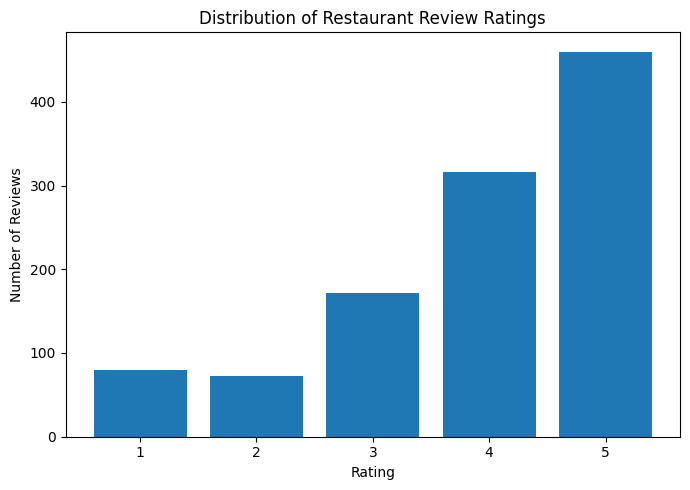

In [187]:
rating_counts = (df['rating'].value_counts().sort_index())
plt.figure(figsize=(7, 5))
plt.bar(rating_counts.index.astype(str),rating_counts.values)
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Restaurant Review Ratings')
plt.tight_layout()
plt.show()

In [188]:
review_length_by_rating = (df.groupby('rating')['review_word_count'].agg(['mean', 'median', 'count']) .round(2))
display(review_length_by_rating)

,mean,median,count
rating,,,
1,21.76,20.0,80
2,23.36,22.0,72
3,20.14,20.0,172
4,20.12,19.0,316
5,19.16,17.0,460


<Figure size 800x500 with 0 Axes>

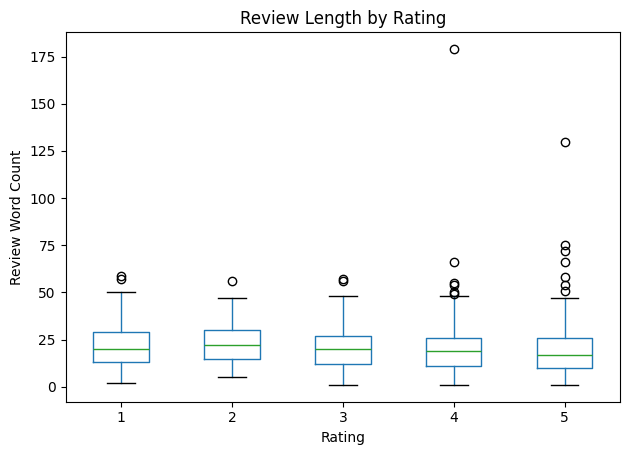

In [189]:
plt.figure(figsize=(8, 5))
df.boxplot(column='review_word_count',by='rating',grid=False)
plt.xlabel('Rating')
plt.ylabel('Review Word Count')
plt.title('Review Length by Rating')
plt.suptitle('')
plt.tight_layout()
plt.show()

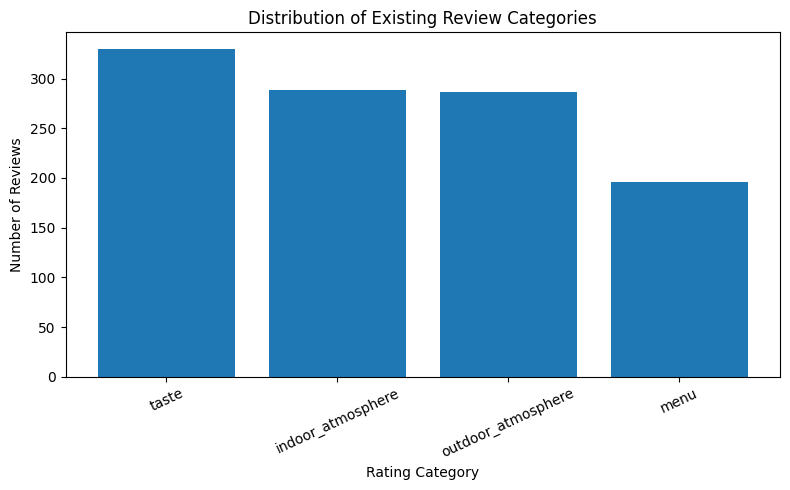

In [190]:
category_counts = (df['rating_category'].value_counts())
plt.figure(figsize=(8, 5))
plt.bar( category_counts.index,category_counts.values)
plt.xlabel('Rating Category')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Existing Review Categories')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [191]:
category_rating_summary = (df.groupby('rating_category')['rating'].agg(['mean', 'median', 'count']).sort_values('mean').round(2))
display(category_rating_summary)

,mean,median,count
rating_category,,,
menu,3.69,4.0,196
taste,3.94,4.0,330
indoor_atmosphere,3.96,4.0,288
outdoor_atmosphere,3.99,4.0,286


In [192]:
restaurant_summary = (df.groupby('business_name').agg(reviews=('text', 'count'),average_rating=('rating', 'mean'),median_rating=('rating', 'median')).sort_values('average_rating'))
display(restaurant_summary.head(10))
display(restaurant_summary.tail(10))

,reviews,average_rating,median_rating
business_name,,,
Medeniyetler Sofrasi,11,3.000000,3.0
Popeyes,11,3.000000,3.0
Salih Usta,11,3.000000,3.0
Baskent Aspava,11,3.090909,3.0
Mado,11,3.181818,3.0
Tavuk Dunyasi,11,3.272727,4.0
KFC,11,3.272727,4.0
Diyarbakir Ocakbasi Palace,11,3.272727,4.0
Cemo Etliekmek,11,3.363636,4.0


,reviews,average_rating,median_rating
business_name,,,
Hasan Usta,11,4.363636,5.0
Pukka Marmaris,11,4.363636,4.0
Cici Tantuni,11,4.363636,4.0
Kumsal Lokantasi,11,4.363636,4.0
Bunbun Kas,11,4.454545,5.0
Churchill Bistro,11,4.454545,5.0
Haci'nin Yeri - Yigit Lokantasi,11,4.454545,5.0
Antakya Mutfagi,11,4.454545,5.0
Yesemek,11,4.454545,5.0


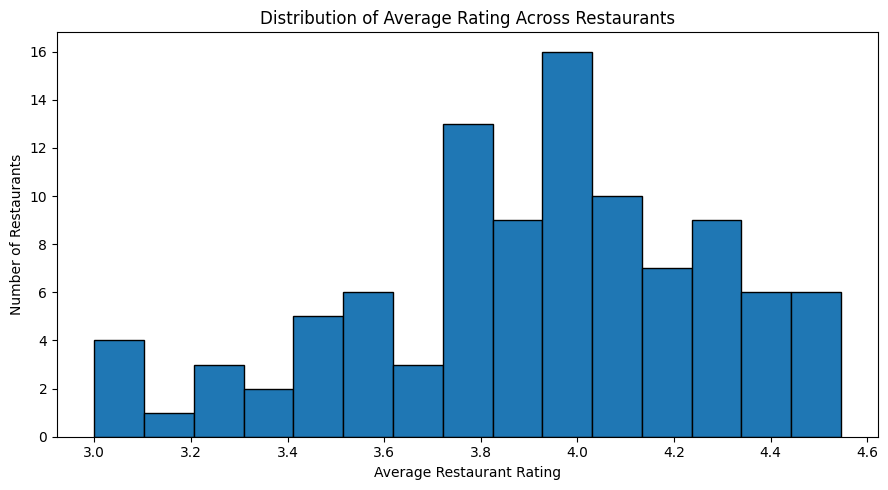

In [193]:
plt.figure(figsize=(9, 5))
plt.hist( restaurant_summary['average_rating'],bins=15,edgecolor='black')
plt.xlabel('Average Restaurant Rating')
plt.ylabel('Number of Restaurants')
plt.title('Distribution of Average Rating Across Restaurants')
plt.tight_layout()
plt.show()

In [194]:
duplicate_texts = df[df.duplicated(subset=['text'],keep=False)
].sort_values('text')
print('Rows involved in duplicate review texts:', len(duplicate_texts))
display(duplicate_texts[['business_name', 'text', 'rating','rating_category']])

Rows involved in duplicate review texts: 19


,business_name,text,rating,rating_category
162,Tatbak,Delicious!,4,taste
321,Sardalye,Delicious!,5,indoor_atmosphere
962,Kadineli,Delicious!,5,outdoor_atmosphere
942,Fikret Balik Restaurant,Expensive place.,1,menu
1050,Lipa,Expensive place.,3,menu
500,Kebabci Halil Usta,Expensive.,3,outdoor_atmosphere
619,Midyeci Ahmet,Expensive.,3,menu
973,Anzelha,Expensive.,3,indoor_atmosphere
72,Gold Semaver,Great.,4,outdoor_atmosphere
228,Salacak,Great.,4,menu


## **3. Data Cleaning Text Preparation**

The dataset has no missing values or completely duplicated rows, according to this exploratory analysis. A few review texts are repeated across different restaurants, but they are primarily brief and general statements.

In [195]:
model_df = df[['business_name','text','rating','rating_category','rating_group', 'review_word_count']].copy()
model_df = model_df.rename( columns={'text': 'text_original'})
print('Modeling dataset shape:', model_df.shape)
display(model_df.head())

Modeling dataset shape: (1100, 6)


,business_name,text_original,rating,rating_category,rating_group,review_word_count
0,Haci'nin Yeri - Yigit Lokantasi,We went to Marmaris with my wife for a holiday. We chose this restaurant as a place for dinner based on the reviews and because we wanted juicy fo...,5,taste,POSITIVE (4-5),130
1,Haci'nin Yeri - Yigit Lokantasi,During my holiday in Marmaris we ate here to fit the food. It's really good that the food is cheap and nice. Eating as much bread as you want is a...,4,menu,POSITIVE (4-5),179
2,Haci'nin Yeri - Yigit Lokantasi,Prices are very affordable. The menu in the photo cost 108 liras. You have to wait 10-15 minutes for food. Staff is annoying. Well it tastes good....,3,outdoor_atmosphere,MIXED (3),31
3,Haci'nin Yeri - Yigit Lokantasi,Turkey's cheapest artisan restaurant and its food is delicious!,5,indoor_atmosphere,POSITIVE (4-5),9
4,Haci'nin Yeri - Yigit Lokantasi,I don't know what you will look for in terms of price performance point; taste; but yigit restaurant writes a big plus for those who come to work ...,3,menu,MIXED (3),31


In [196]:
def clean_review_text(text):
    text = str(text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\s+([,.!?;:])',r'\1',text)
    return text.strip()
model_df['text_clean'] = ( model_df['text_original'].apply(clean_review_text))
display(model_df[['text_original','text_clean']].head(10))

,text_original,text_clean
0,We went to Marmaris with my wife for a holiday. We chose this restaurant as a place for dinner based on the reviews and because we wanted juicy fo...,We went to Marmaris with my wife for a holiday. We chose this restaurant as a place for dinner based on the reviews and because we wanted juicy fo...
1,During my holiday in Marmaris we ate here to fit the food. It's really good that the food is cheap and nice. Eating as much bread as you want is a...,During my holiday in Marmaris we ate here to fit the food. It's really good that the food is cheap and nice. Eating as much bread as you want is a...
2,Prices are very affordable. The menu in the photo cost 108 liras. You have to wait 10-15 minutes for food. Staff is annoying. Well it tastes good....,Prices are very affordable. The menu in the photo cost 108 liras. You have to wait 10-15 minutes for food. Staff is annoying. Well it tastes good....
3,Turkey's cheapest artisan restaurant and its food is delicious!,Turkey's cheapest artisan restaurant and its food is delicious!
4,I don't know what you will look for in terms of price performance point; taste; but yigit restaurant writes a big plus for those who come to work ...,I don't know what you will look for in terms of price performance point; taste; but yigit restaurant writes a big plus for those who come to work ...
5,Generally good.,Generally good.
6,What you see is 125 TL in total. It's a pretty convenient place. We can say that it is an artisan restaurant; you should not expect a restaurant; ...,What you see is 125 TL in total. It's a pretty convenient place. We can say that it is an artisan restaurant; you should not expect a restaurant; ...
7,Delicious food at rock bottom prices. Friendly staff; Highly recommend,Delicious food at rock bottom prices. Friendly staff; Highly recommend
8,"Every time I go, I still experience the amazement I experienced years ago as if it were the first time. There is no need to explain. Folk hero is ...","Every time I go, I still experience the amazement I experienced years ago as if it were the first time. There is no need to explain. Folk hero is ..."
9,The most f/p of all businesses I've seen.,The most f/p of all businesses I've seen.


### **3.1 Validate Cleaning**

In [197]:
print( 'Empty cleaned reviews:',(model_df['text_clean'].str.len() == 0).sum())
print('Unique original texts:', model_df['text_original'].nunique())
print('Unique cleaned texts:',model_df['text_clean'].nunique())
print('Average words per review:',round(model_df['review_word_count'].mean(),2))

Empty cleaned reviews: 0
Unique original texts: 1088
Unique cleaned texts: 1088
Average words per review: 20.05


In [198]:
short_reviews = (model_df.sort_values('review_word_count')[['business_name', 'text_clean','rating', 'rating_category','review_word_count']].head(20))
display(short_reviews)

,business_name,text_clean,rating,rating_category,review_word_count
534,Kasikla Restaurant,Recommend.,5,outdoor_atmosphere,1
544,Askin Tostevi,Liked.,4,outdoor_atmosphere,1
500,Kebabci Halil Usta,Expensive.,3,outdoor_atmosphere,1
582,Kaliteci,Loved.,5,outdoor_atmosphere,1
424,Bilice,Great.,5,indoor_atmosphere,1
619,Midyeci Ahmet,Expensive.,3,menu,1
72,Gold Semaver,Great.,4,outdoor_atmosphere,1
293,Nazar Cafe,Good.,4,menu,1
962,Kadineli,Delicious!,5,outdoor_atmosphere,1
296,Nazar Cafe,Recommend.,4,indoor_atmosphere,1


## **4. Problem Formulation and Technique Selection**

Instead of predicting a predetermined result, the client's objective is to identify recurrent themes in restaurant review text. Labels like 'slow service,' 'cleanliness problem,' 'high prices,' and 'food quality issue' are absent from the dataset.
Therefore, this is primarily an **unsupervised pattern-discovery problem**.

The analysis will compare two approaches:

1. **TF-IDF + K-Means** as a transparent baseline that groups reviews based on shared words and phrases.
2. **Sentence embeddings + semantic clustering** as a stronger approach that can recognize reviews with similar meanings even when they use different vocabulary.

The clustering features purposefully do not include ratings. They are then used to describe each theme that has been identified as having a tendency toward positive, negative experiences.

A clustering metric by itself will not be used to choose the final model. Theme clarity, cluster separation, representative reviews, and stakeholder utility will all be taken into account.

## **5. Baseline Model - TF-IDF+K-Means**

K-Means clustering comes after the first clustering method, which uses TF-IDF to represent each review according to its key words and phrases.The top terms in each cluster can be directly examined, making it transparent and easy to inspect. This helps determine whether the resulting groups correspond to significant review themes.

The model is trained on the entire corpus of cleaned reviews, as requested by the client. Ratings are used to interpret the resulting clusters, not as clustering features.

**5.1 Build TF-IDF features**

In [199]:
tfidf_vectorizer = TfidfVectorizer(lowercase=True,stop_words='english',ngram_range=(1, 2),min_df=3, max_df=0.90,max_features=3000)
X_tfidf = tfidf_vectorizer.fit_transform( model_df['text_clean'])
print('TF-IDF matrix shape:', X_tfidf.shape)

TF-IDF matrix shape: (1100, 957)


**5.2 Compare K values**

In [200]:
k_values = range(3, 13)

tfidf_inertias = []
tfidf_silhouettes = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_tfidf)

    tfidf_inertias.append(
        model.inertia_
    )

    tfidf_silhouettes.append(
        silhouette_score(
            X_tfidf,
            labels,
            metric='cosine'
        )
    )

results_k = pd.DataFrame({
    'K': list(k_values),
    'Inertia': tfidf_inertias,
    'Silhouette': tfidf_silhouettes
})

display(results_k)

,K,Inertia,Silhouette
0,3,1053.553740,0.018478
1,4,1047.411588,0.018712
2,5,1040.430634,0.022985
3,6,1035.406843,0.023944
4,7,1027.677288,0.026198
5,8,1021.838178,0.030422
6,9,1016.449341,0.030466
7,10,1010.815548,0.032570
8,11,1005.971270,0.038919
9,12,998.844463,0.042166


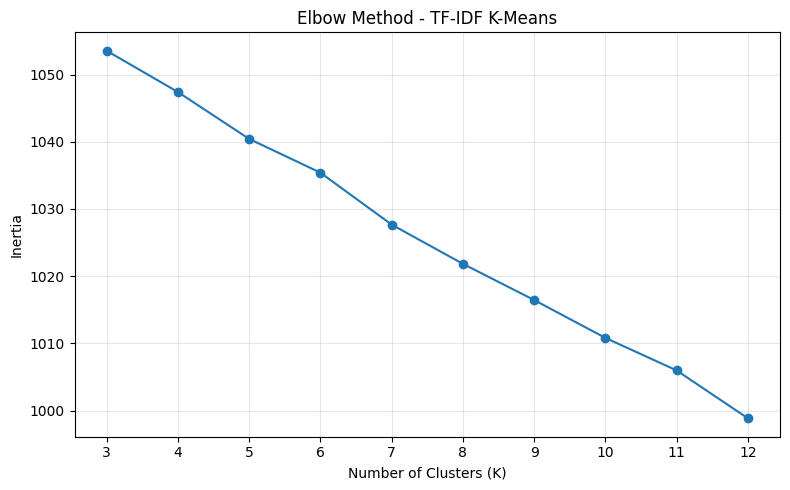

In [201]:
plt.figure(figsize=(8, 5))
plt.plot( results_k['K'], results_k['Inertia'],marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method - TF-IDF K-Means')
plt.xticks(list(k_values))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

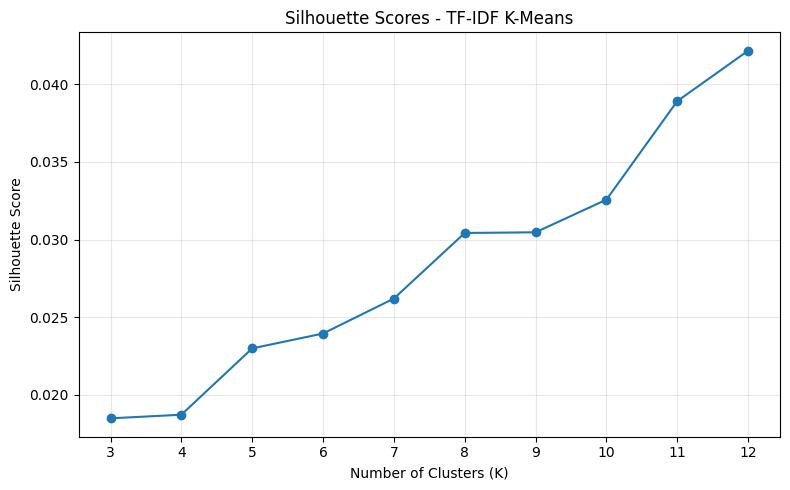

In [202]:
plt.figure(figsize=(8, 5))
plt.plot(results_k['K'], results_k['Silhouette'],marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores - TF-IDF K-Means')
plt.xticks(list(k_values))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**5.3 Inspect several candidate K values**

In [204]:
candidate_k_values = [5, 6, 7, 8]

In [205]:
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
def inspect_tfidf_clusters(k):
    model = KMeans( n_clusters=k,random_state=42,n_init=20)

    labels = model.fit_predict(X_tfidf)
    model_df[f'tfidf_cluster_{k}'] = labels
    print('-' * 70)
    print(f'K = {k}')
    print('-' * 70)
    for cluster_id in range(k):
        print(f'\nCluster {cluster_id}')
        centroid = model.cluster_centers_[cluster_id]
        top_indices = centroid.argsort()[-10:][::-1]
        top_terms = feature_names[top_indices]
        print('Top terms:', ', '.join(top_terms))
        cluster_reviews = model_df[model_df[f'tfidf_cluster_{k}'] == cluster_id]
        print('Reviews:',len(cluster_reviews))
        display(cluster_reviews[
                ['business_name','text_original', 'rating','rating_category']].head(5) )

In [ ]:
for k in candidate_k_values:
    inspect_tfidf_clusters(k)

### 5.4 What We're Looking For

A useful cluster should contain **semantically related terms and reviews that point to a clear, actionable theme**.

For example:

**Top terms:**  
`expensive`, `price`, `overpriced`, `money`, `portion`, `worth`

**Representative reviews:**
- "The food was good but too expensive."
- "Prices are ridiculous for the portion size."
- "Not worth the money."

This cluster could be confidently interpreted as:

**Price / Value Concerns**

In contrast, a weak cluster might contain broad terms such as:

`good`, `place`, `restaurant`, `nice`, `food`

If its representative reviews discuss several unrelated topics, the cluster would be too broad to provide a meaningful or actionable interpretation.

The goal is therefore not simply to create mathematically distinct clusters, but to identify themes that are **coherent, interpretable, and useful to the stakeholder**.

**5.5 Add a cluster profile function**

In [206]:
chosen_k_tfidf = 6

tfidf_kmeans = KMeans( n_clusters=chosen_k_tfidf,random_state=42, n_init=20)
model_df['tfidf_cluster'] = ( tfidf_kmeans.fit_predict(X_tfidf))

In [207]:
tfidf_cluster_summary = (model_df .groupby('tfidf_cluster').agg(
        reviews=('text_original', 'count'),restaurants=('business_name', 'nunique'),average_rating=('rating', 'mean'),median_rating=('rating', 'median'),average_words=('review_word_count', 'mean')).round(2))
display(tfidf_cluster_summary)

,reviews,restaurants,average_rating,median_rating,average_words
tfidf_cluster,,,,,
0,476,99,3.69,4.0,21.15
1,189,83,3.75,4.0,20.65
2,89,57,4.19,5.0,20.55
3,63,45,4.57,5.0,13.76
4,145,76,3.99,4.0,19.98
5,138,76,4.34,5.0,18.08


In [208]:
tfidf_category_profile = pd.crosstab(model_df['tfidf_cluster'],model_df['rating_category'],normalize='index') * 100
display(tfidf_category_profile.round(1))

rating_category,indoor_atmosphere,menu,outdoor_atmosphere,taste
tfidf_cluster,,,,
0,26.1,18.7,25.2,30.0
1,29.1,15.3,27.5,28.0
2,16.9,20.2,28.1,34.8
3,27.0,15.9,30.2,27.0
4,27.6,21.4,26.9,24.1
5,26.8,13.8,22.5,37.0


In [ ]:
for k in [10, 11, 12]:
    inspect_tfidf_clusters(k)

### Baseline Model Selection

When the TF-IDF baseline was tested with K values ranging from 3 to 12, the silhouette scores stayed low in all configurations, suggesting that the review text does not naturally split into highly distinct keyword-based clusters. Nevertheless, this baseline's goal goes beyond simple numerical separation. Additionally, the clusters must generate themes that the stakeholder can comprehend and utilize.

K = 11 was chosen as the baseline configuration after representative reviews and top terms were examined. Price concerns, delayed or incorrect orders, poor service, ambiance, and positive recommendation-oriented reviews are some of the relatively obvious themes that emerged from this.
 When reviews express similar ideas using different vocabulary, TF-IDF may be limited, as evidenced by the fact that some clusters remained broad and mixed. This encourages the next step to test a semantic text representation.

In [209]:
chosen_k_tfidf = 11
tfidf_kmeans = KMeans( n_clusters=chosen_k_tfidf,random_state=42, n_init=20)
model_df['tfidf_cluster'] = (tfidf_kmeans.fit_predict(X_tfidf))

In [210]:
baseline_summary = ( model_df.groupby('tfidf_cluster') .agg(reviews=('text_original', 'count'), restaurants=('business_name', 'nunique'), average_rating=('rating', 'mean'),median_rating=('rating', 'median'), average_words=('review_word_count', 'mean')).round(2))
display(baseline_summary)

,reviews,restaurants,average_rating,median_rating,average_words
tfidf_cluster,,,,,
0,36,28,4.33,5.0,22.39
1,126,72,4.34,5.0,17.14
2,46,37,3.50,4.0,23.54
3,54,35,3.35,3.0,16.78
4,46,39,2.61,3.0,19.15
5,152,75,3.85,4.0,21.81
6,347,97,3.81,4.0,21.89
7,123,69,4.12,4.0,18.24
8,104,60,4.20,4.0,19.82


In [211]:
baseline_terms = []

for cluster_id in range(chosen_k_tfidf):
    centroid = tfidf_kmeans.cluster_centers_[cluster_id]
    top_indices = centroid.argsort()[-10:][::-1]
    top_terms = feature_names[top_indices]
    baseline_terms.append({'cluster': cluster_id, 'top_terms': ', '.join(top_terms)  })
baseline_terms_df = pd.DataFrame( baseline_terms)

display(baseline_terms_df)

,cluster,top_terms
0,0,"liked, really, really liked, doner, place, tried, ate, especially, turkish, good"
1,1,"delicious, food, service, reasonable, food delicious, fresh, delicious food, really delicious, place, prices"
2,2,"came, order, late, cold, came late, orders came, food came, came cold, orders, order came"
3,3,"expensive, expensive place, place, little expensive, little, good, bit expensive, prices, taste, expensive restaurant"
4,4,"bad, wasn, service, bad service, taste, wasn bad, food, food bad, didn, good"
5,5,"taste, prices, high, amazing, good, price, prices high, terms, service, reasonable"
6,6,"recommend, place, pizza, excellent, like, service, best, eat, menu, ate"
7,7,"good, service, place, lahmacun, food, ate, service good, pretty, good service, fish"
8,8,"nice, place, ambiance, place nice, food, nice place, good, nice food, staff, breakfast"
9,9,"ice, ice cream, cream, fethiye, milk, road, attention, nice, center, delicious ice"


## **6. Semantic Clustering with Sentence Embeddings**

Because similar ideas can be expressed using different vocabulary, some groups remained broad or mixed even tho several useful clusters emerged from the TF--IDF baseline grouping reviews based primarily on shared words and phrases. In order to overcome this constraint, the subsequent model employs sentence embeddings, which represent the review's overall semantic meaning in a dense vector space rather than each review as a sparse wordfrequency vector.

K-Means is once more employed as the clustering algorithm to ensure a fair comparison. This makes it possible to compare the text representation's impact to the TF-IDF baseline.

In [212]:
embedding_model = SentenceTransformer( 'all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

**6.1 Generate embeddings**

In [213]:
review_embeddings = embedding_model.encode(model_df['text_clean'].tolist(),show_progress_bar=True,normalize_embeddings=True)
print('Embedding matrix shape:', review_embeddings.shape)

Batches:   0%|          | 0/35 [00:00<?, ?it/s]

Embedding matrix shape: (1100, 384)


**6.2 Compare K values**

In [214]:
semantic_k_values = range(3, 13)
semantic_inertias = []
semantic_silhouettes = []

for k in semantic_k_values:
    model = KMeans(n_clusters=k, random_state=42,n_init=20 )

    labels = model.fit_predict(
        review_embeddings
    )

    semantic_inertias.append(
        model.inertia_
    )

    semantic_silhouettes.append(
        silhouette_score(
            review_embeddings,
            labels,
            metric='cosine'
        )
    )

semantic_results = pd.DataFrame({'K': list(semantic_k_values), 'Inertia': semantic_inertias,'Silhouette': semantic_silhouettes})

display(semantic_results)

C:\Users\tawsi\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\tawsi\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\tawsi\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\tawsi\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

,K,Inertia,Silhouette
0,3,745.895020,0.056726
1,4,729.817749,0.059133
2,5,715.221741,0.068078
3,6,707.084534,0.063283
4,7,699.047729,0.065422
5,8,691.644043,0.064668
6,9,687.122864,0.067407
7,10,681.491760,0.060073
8,11,674.738831,0.063942
9,12,670.854736,0.050753


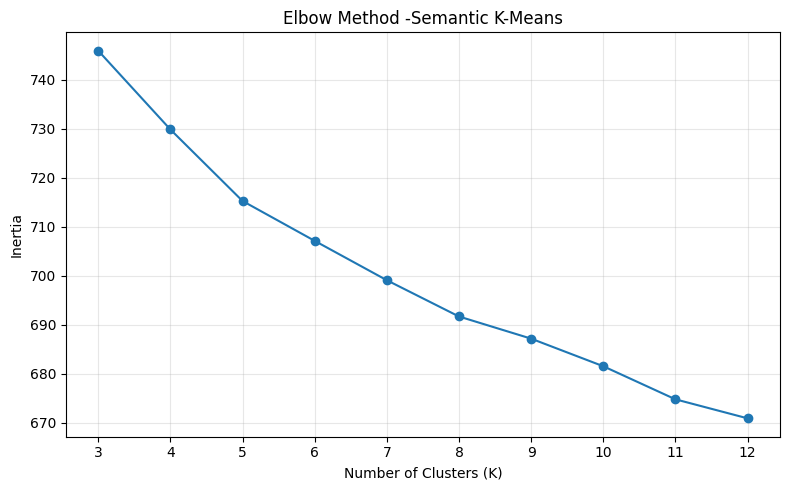

In [215]:
plt.figure(figsize=(8, 5))
plt.plot(semantic_results['K'], semantic_results['Inertia'],marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method -Semantic K-Means')
plt.xticks(list(semantic_k_values))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

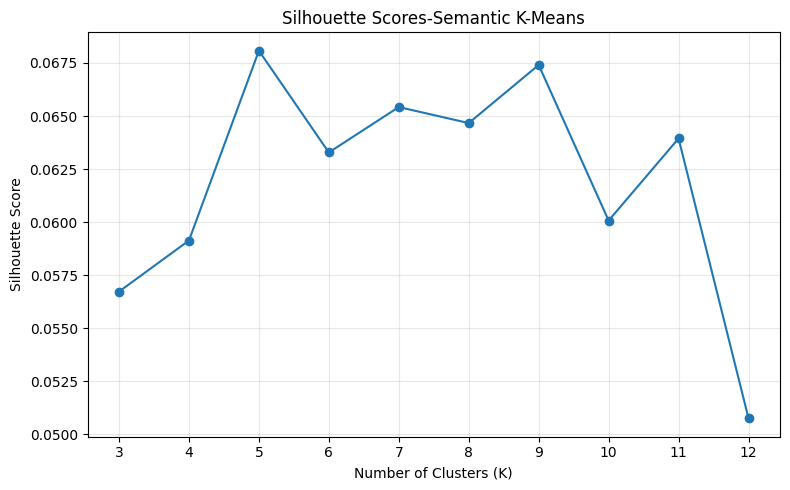

In [216]:
plt.figure(figsize=(8, 5))
plt.plot(semantic_results['K'],semantic_results['Silhouette'],marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores-Semantic K-Means')
plt.xticks(list(semantic_k_values))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**6.3 Inspect candidate semantic clusters**

In [217]:
def inspect_semantic_clusters(k, n_examples=5):
    model = KMeans(n_clusters=k, random_state=42,n_init=20)

    labels = model.fit_predict(
        review_embeddings
    )

    print('=' * 70)
    print(f'Semantic K = {k}')
    print('=' * 70)
    for cluster_id in range(k):
        cluster_indices = np.where(
            labels == cluster_id
        )[0]

        cluster_embeddings = (
            review_embeddings[
                cluster_indices
            ]
        )

        centroid = (
            model.cluster_centers_[
                cluster_id
            ]
            .reshape(1, -1)
        )

        similarities = cosine_similarity(
            cluster_embeddings,
            centroid
        ).flatten()

        closest_positions = (
            np.argsort(similarities)[::-1]
            [:n_examples]
        )

        representative_indices = (
            cluster_indices[
                closest_positions
            ]
        )

        print(
            f'\nCluster {cluster_id}'
        )

        print(
            'Reviews:',
            len(cluster_indices)
        )

        display(
            model_df.iloc[
                representative_indices
            ][
                [
                    'business_name',
                    'text_original',
                    'rating',
                    'rating_category'
                ]
            ]
        )

In [ ]:
for k in [6, 8, 10, 11, 12]:
    inspect_semantic_clusters(k, n_examples=5)

### Semantic K-Means Results

Sentence embeddings produced more meaningful cluster separation than the TF-IDF baseline- model achieved higher silhouette scores and was better able to group reviews that discussed similar experiences using different vocabulary.

Several clusters began to represent recognizable restaurant experience themes such as service quality, pricing and value, cleanliness, ambiance, food quality, and waiting time.

However, some clusters still combined multiple issues or grouped reviews around specific food types rather than stakeholder relevant complaint themes. Because K-Means forces every review into a cluster, a density-based semantic clustering approach will also be tested before selecting the final model.

In [218]:
hdbscan_settings = [(10, 5),(15, 5),(20, 5),(20, 10),(25, 10),(30, 10)]
hdbscan_results = []

for min_cluster_size, min_samples in hdbscan_settings:
    clusterer = hdbscan.HDBSCAN( min_cluster_size=min_cluster_size,min_samples=min_samples,metric='euclidean',cluster_selection_method='eom')

    labels = clusterer.fit_predict(
        review_embeddings
    )

    n_clusters = len(
        set(labels)
        - {-1}
    )

    noise_points = (
        labels == -1
    ).sum()

    clustered_mask = (
        labels != -1
    )

    if (
        n_clusters > 1
        and clustered_mask.sum() > n_clusters
    ):
        score = silhouette_score(
            review_embeddings[
                clustered_mask
            ],
            labels[
                clustered_mask
            ],
            metric='cosine'
        )
    else:
        score = np.nan

    hdbscan_results.append({'min_cluster_size': min_cluster_size, 'min_samples': min_samples,'clusters': n_clusters, 'noise': noise_points,'noise_percent':noise_points / len(labels) * 100,'silhouette': score})
hdbscan_results_df = pd.DataFrame(hdbscan_results)
display(hdbscan_results_df)

,min_cluster_size,min_samples,clusters,noise,noise_percent,silhouette
0,10,5,0,1100,100.0,NaN
1,15,5,0,1100,100.0,NaN
2,20,5,0,1100,100.0,NaN
3,20,10,0,1100,100.0,NaN
4,25,10,0,1100,100.0,NaN
5,30,10,0,1100,100.0,NaN


### Direct HDBSCAN Attempt

When HDBSCAN was first applied directly to the 384 dimensional sentence embeddings across the tested parameter settings, no valid clusters were formed and all 1,100 reviews were categorized as noise. Silhouette scores could not be computed as a result, indicating that it is challenging to directly identify density structure in the high dimensional embedding space. Therefore, before using HDBSCAN once more, a dimensionality-reduction step is tested.

## **7. UMAP + HDBSCAN**

All reviews were categorized as noise when HDBSCAN was applied directly to the 384-dimensional sentence embeddings. The semantic embeddings are first reduced to a lower dimensional space using UMAP in order to facilitate the identification of density structure.

The reduced representation is then subjected to HDBSCAN, which, in contrast to K-Means, can identify ambiguous reviews as noise and does not force every review into a cluster.

**7.1 Reduce the embeddings**

In [219]:
umap_model = umap.UMAP( n_neighbors=15, n_components=5,min_dist=0.0,metric='cosine',random_state=42)

review_embeddings_umap = umap_model.fit_transform(review_embeddings)
print('Reduced embedding shape:',review_embeddings_umap.shape)

C:\Users\tawsi\miniconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced embedding shape: (1100, 5)


**7.2 Test HDBSCAN settings**

In [220]:
hdbscan_settings = [
    (10, 3),
    (10, 5),
    (15, 3),
    (15, 5),
    (20, 5),
    (25, 5),
    (30, 5)
]

umap_hdbscan_results = []

for min_cluster_size, min_samples in hdbscan_settings:

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric='euclidean',
        cluster_selection_method='eom'
    )

    labels = clusterer.fit_predict(
        review_embeddings_umap
    )

    n_clusters = len(
        set(labels) - {-1}
    )

    noise_points = (
        labels == -1
    ).sum()

    clustered_mask = (
        labels != -1
    )

    if (
        n_clusters > 1
        and clustered_mask.sum() > n_clusters
    ):
        score = silhouette_score(
            review_embeddings[
                clustered_mask
            ],
            labels[
                clustered_mask
            ],
            metric='cosine'
        )
    else:
        score = np.nan

    umap_hdbscan_results.append({
        'min_cluster_size': min_cluster_size,
        'min_samples': min_samples,
        'clusters': n_clusters,
        'noise': noise_points,
        'noise_percent':
            noise_points / len(labels) * 100,
        'silhouette': score
    })

umap_hdbscan_results_df = pd.DataFrame(
    umap_hdbscan_results
)

display(
    umap_hdbscan_results_df
)

,min_cluster_size,min_samples,clusters,noise,noise_percent,silhouette
0,10,3,38,318,28.909091,0.092959
1,10,5,35,335,30.454545,0.092347
2,15,3,20,246,22.363636,0.064551
3,15,5,20,378,34.363636,0.094764
4,20,5,14,278,25.272727,0.040944
5,25,5,11,293,26.636364,0.038841
6,30,5,2,50,4.545455,0.015471


**7.3 What a useful result looks like**

We are looking for something roughly like:

clusters: 6-15
noise: maybe 5-35%

**7.4 Pick one candidate and inspect it**

In [221]:
final_hdbscan = hdbscan.HDBSCAN( min_cluster_size=15,min_samples=5, metric='euclidean',cluster_selection_method='eom')
hdbscan_labels = final_hdbscan.fit_predict( review_embeddings_umap)
model_df['hdbscan_cluster'] = (hdbscan_labels)

print(model_df['hdbscan_cluster'].value_counts().sort_index())

hdbscan_cluster
-1     378
 0      42
 1      26
 2      19
 3      27
 4      33
 5      27
 6      16
 7      20
 8      24
 9      55
 10     24
 11     33
 12     35
 13     36
 14     23
 15     19
 16     93
 17     32
 18     31
 19    107
Name: count, dtype: int64


**7.5 Inspect representative reviews**

In [222]:
model_df['hdbscan_probability'] = (final_hdbscan.probabilities_)

In [223]:
for cluster_id in sorted(
    model_df['hdbscan_cluster'].unique()
):

    if cluster_id == -1:
        continue

    cluster_reviews = (
        model_df[
            model_df['hdbscan_cluster']
            == cluster_id
        ]
        .sort_values(
            'hdbscan_probability',
            ascending=False
        )
    )

    print(
        f'\nCluster {cluster_id}'
    )

    print(
        'Reviews:',
        len(cluster_reviews)
    )

    display(
        cluster_reviews[
            [ 'business_name', 'text_original',  'rating', 'rating_category', 'hdbscan_probability']
        ].head(5)
    )


Cluster 0
Reviews: 42


,business_name,text_original,rating,rating_category,hdbscan_probability
14,Pizza Fellas,They make delicious pizza with nice ingredients on thin dough. Slice pizza and all pizza options are available. You can try two different flavors ...,5,outdoor_atmosphere,1.0
15,Pizza Fellas,It's in a nice place but it's very small and their pizza is not that good to be exaggerated. Pizza dough is nice and thin. They do not offer advic...,3,taste,1.0
17,Pizza Fellas,It is very tasty; similar to Italian pizzas. Roast beef and mohair 180 TL; other pizzas 150 TL. An adult male eats 6 slices; pizzas are one size a...,4,menu,1.0
18,Pizza Fellas,Do not come around Marmaris and do not leave without eating pizza at Pizza Fellas. We ate mixed pizza; they can make two types of pizza. So delici...,5,taste,1.0
24,Cafe Inn,Pizza is delicious.. I can say it is one of the rare tastes. Prices are in the 200-300 range and one pizza is more than enough for two people if y...,5,indoor_atmosphere,1.0



Cluster 1
Reviews: 26


,business_name,text_original,rating,rating_category,hdbscan_probability
5,Haci'nin Yeri - Yigit Lokantasi,Generally good.,4,indoor_atmosphere,1.0
72,Gold Semaver,Great.,4,outdoor_atmosphere,1.0
79,Fethiye Dondurmacisi,Absolutely perfect come try it..,5,outdoor_atmosphere,1.0
159,Tatbak,Awesomeee,5,taste,1.0
216,Vefa Bozacisi,Perfect!,5,taste,1.0



Cluster 2
Reviews: 19


...

,business_name,text_original,rating,rating_category,hdbscan_probability
100,Mcdonalds Fethiye,"I would like to thank the service in Fethiye branch and especially Mr. Samet; the official here, for his interest and relevance.",4,taste,1.0
347,Kofteci Yusuf,Great service; attention and relevance It was nice. Everything was perfect.,5,indoor_atmosphere,1.0
344,Kofteci Yusuf,Great service.,4,menu,1.0
241,Nusr-et,He's very successful. Even though it was very crowded; the service was incredibly fast.,5,taste,1.0
459,Backyard,The service provided was very nice; I was happy.,5,outdoor_atmosphere,1.0



Cluster 18
Reviews: 31


,business_name,text_original,rating,rating_category,hdbscan_probability
37,Riviera,The staff was very engaged. Service and taste were perfect.,4,indoor_atmosphere,1.0
147,Leman Kultur,Good salep was good; the employees were smiling..,4,indoor_atmosphere,1.0
130,Starbucks Bodrum,Employees are very warm. in a very pleasant location.,5,indoor_atmosphere,1.0
170,Guzel Koy Cafe,We were very satisfied from the staff to the meal.,5,taste,1.0
177,Cemo Etliekmek,Employees are kind. Food is delicious,5,indoor_atmosphere,1.0



Cluster 19
Reviews: 107


,business_name,text_original,rating,rating_category,hdbscan_probability
13,Pizza Fellas,It is in the center; easy to reach; close to the parking lot; the prices are partially affordable; the products are delicious but not quite satisf...,4,indoor_atmosphere,1.0
22,Cafe Inn,The environment; the interest and friendliness of the employees; the taste is incredible. It is so beautiful inside that you do not prefer to sit ...,5,indoor_atmosphere,1.0
29,Cafe Inn,Nice intimate restaurant. Good service. Eye for detail. Clean. Really good food; well presented.,5,outdoor_atmosphere,1.0
38,Riviera,Perfect location next to the sea. Music; light in the evening lounge atmosphere. In short; everything is beautiful.,4,outdoor_atmosphere,1.0
43,Riviera,Nice food and good service; located just near the beach as well.,5,indoor_atmosphere,1.0


In [224]:
noise_reviews = model_df[ model_df['hdbscan_cluster'] == -1]

print('Noise reviews:',len(noise_reviews))

display( noise_reviews[
        ['business_name', 'text_original', 'rating','rating_category' ]].head(10))

Noise reviews: 378


,business_name,text_original,rating,rating_category
0,Haci'nin Yeri - Yigit Lokantasi,We went to Marmaris with my wife for a holiday. We chose this restaurant as a place for dinner based on the reviews and because we wanted juicy fo...,5,taste
4,Haci'nin Yeri - Yigit Lokantasi,I don't know what you will look for in terms of price performance point; taste; but yigit restaurant writes a big plus for those who come to work ...,3,menu
6,Haci'nin Yeri - Yigit Lokantasi,What you see is 125 TL in total. It's a pretty convenient place. We can say that it is an artisan restaurant; you should not expect a restaurant; ...,5,taste
8,Haci'nin Yeri - Yigit Lokantasi,"Every time I go, I still experience the amazement I experienced years ago as if it were the first time. There is no need to explain. Folk hero is ...",5,outdoor_atmosphere
9,Haci'nin Yeri - Yigit Lokantasi,The most f/p of all businesses I've seen.,5,indoor_atmosphere
11,Pizza Fellas,The ambiance of the place is nice; when we went; there was a lot of queue; and after waiting for a while; they took our place. The friend who took...,5,indoor_atmosphere
12,Pizza Fellas,"Flavor : It has nothing but dough taste. Labor : Not befitting a touristic place. Service : There was no wet wipes and napkins on the table, but t...",2,taste
33,Riviera,"It is a very, very expensive place. It took 30 minutes for 2 drinks to arrive.",3,menu
35,Riviera,quality service and rich menu. the attitude of the staff is really excellent. A business that deserves 5 stars.,5,outdoor_atmosphere
36,Riviera,The sushi was too small so it was not possible to taste the ingredients; the rice was overcooked and lacked flavor; it was missing except for the ...,2,taste


## 8. Final Model Selection

Three clustering approaches were evaluated:

1. **TF-IDF + K-Means**
2. **SentenceTransformer embeddings + K-Means**
3. **SentenceTransformer embeddings + UMAP + HDBSCAN**

The analysis shows that unsupervised semantic clustering can convert unprocessed restaurant reviews into comprehensible themes that are more valuable than just ratings. Price/value, waiting time, staff/service quality, and cleanliness or environment were the strongest operational patterns. While some themes were heavily concentrated at specific establishments, others were prevalent throughout restaurants.

Additionally, the project demonstrated the significance of model comparison. Semantic embeddings enhanced thematic coherence, TF-IDF offered a transparent baseline, and HDBSCAN identified niche patterns but added significant fragmentation and noise.

All things considered, the final semantic K-Means model offered the best compromise between stakeholder utility, interpretability, and review coverage.

### 8.1 Final Model Comparison

Cluster separation, review coverage, and qualitative interpretability were used to compare the three methods. Since stakeholder usefulness also depends on whether clusters are coherent, comprehensible, and sufficiently comprehensive, the Silhouette score was treated as one evaluation signal rather than the only selection criterion.
| Model                         | Selected Configuration                               | Silhouette Score | Review Coverage | Interpretation                                                                                                    |
| ----------------------------- | ---------------------------------------------------- | ---------------: | --------------: | ----------------------------------------------------------------------------------------------------------------- |
| TF-IDF + K-Means              | K = 11                                               |            0.039 |            100% | Transparent baseline, but several clusters were driven by shared vocabulary and remained broad or mixed           |
| SentenceTransformer + K-Means | K = 11                                               |            0.064 |            100% | Produced more semantically coherent themes while retaining every review                                           |
| UMAP + HDBSCAN                | 20 clusters (`min_cluster_size=15`, `min_samples=5`) |            0.095 |           65.6% | Identified specific niche themes, but produced substantial fragmentation and classified 34.4% of reviews as noise |

**Final selection:** SentenceTransformer embeddings with K-Means (`K = 11`) were selected as the main model. While UMAP + HDBSCAN had the highest silhouette score, its greater fragmentation and lower review coverage made it less useful for stakeholder-facing and restaurant-level analysis. As a result, HDBSCAN was kept as a supporting experiment.

In [255]:
final_k = 11
final_semantic_model = KMeans( n_clusters=final_k, random_state=42,n_init=20)
model_df['final_cluster'] = (final_semantic_model.fit_predict(review_embeddings))

C:\Users\tawsi\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


In [226]:
final_cluster_summary = (model_df.groupby('final_cluster') .agg(reviews=('text_original', 'count'),restaurants=('business_name', 'nunique'),average_rating=('rating', 'mean'),median_rating=('rating', 'median'),average_words=('review_word_count', 'mean')) .round(2))
display(final_cluster_summary)

,reviews,restaurants,average_rating,median_rating,average_words
final_cluster,,,,,
0,86,48,3.72,4.0,20.42
1,116,60,4.25,4.0,24.60
2,175,76,4.20,5.0,22.48
3,128,67,3.75,4.0,19.51
4,42,10,4.19,5.0,24.50
5,119,66,3.31,3.0,20.87
6,78,54,3.27,4.0,16.24
7,66,50,3.36,3.0,17.47
8,66,31,3.86,4.0,21.29


In [227]:
final_rating_profile = pd.crosstab( model_df['final_cluster'], model_df['rating_group'],normalize='index') * 100
display( final_rating_profile.round(1))

rating_group,NEGATIVE (1-2),MIXED (3),POSITIVE (4-5)
final_cluster,,,
0,20.9,14.0,65.1
1,4.3,12.1,83.6
2,8.6,12.6,78.9
3,13.3,21.9,64.8
4,11.9,9.5,78.6
5,31.1,19.3,49.6
6,33.3,14.1,52.6
7,19.7,33.3,47.0
8,10.6,18.2,71.2


## **9. Theme Interpretation and Validation**

The final semantic K-Means model produced 11 clusters, because unsupervised clustering does not automatically provide meaningful human readable labels, each cluster must be interpreted using its representative reviews, common terms, rating profile and restaurant coverage.

Cluster labels are assigned manually only when the underlying reviews show a sufficiently coherent and understandable theme. Clusters that mix several unrelated ideas are identified as broad or mixed rather than being given an artificially specific label.

In [228]:
from sklearn.metrics.pairwise import cosine_similarity
representative_reviews = {}
for cluster_id in range(final_k):

    cluster_indices = np.where(
        model_df['final_cluster'].values == cluster_id
    )[0]

    cluster_embeddings = review_embeddings[
        cluster_indices
    ]

    centroid = final_semantic_model.cluster_centers_[
        cluster_id
    ].reshape(1, -1)

    similarities = cosine_similarity(
        cluster_embeddings,
        centroid
    ).flatten()

    closest_positions = np.argsort(
        similarities
    )[::-1][:10]

    representative_indices = cluster_indices[
        closest_positions
    ]

    representative_reviews[cluster_id] = (
        model_df.iloc[representative_indices][
            [
                'business_name',
                'text_original',
                'rating',
                'rating_category'
            ]
        ]
    )

    print('*' * 70)
    print(f'CLUSTER {cluster_id}')
    print('*' * 70)

    display(
        representative_reviews[cluster_id]
    )

**********************************************************************
CLUSTER 0
**********************************************************************


,business_name,text_original,rating,rating_category
509,Abidin Tantuni,The taste is good but not satisfying.,4,menu
699,Rumeli Iskembecisi,The taste is excellent; the portion size is good; the price is a bit expensive.,5,taste
315,Sushico,The flavors were good in general; the prices were a bit high.,4,menu
1017,Popeyes,The taste is not bad in general; but you can eat better ones in other restaurants.,4,taste
508,Abidin Tantuni,it tasted so good that I even ordered and ate the second one!,5,indoor_atmosphere
320,Sardalye,The taste really lives up to expectations. It is a business that maintains frying fish; which is essentially a fast food; in accordance with its c...,4,taste
269,Bunbun Kas,I really liked the handmade basil buttermilk and lemonade. The chicken sandwich is okay; I think the chocolate one has nothing to say; it only had...,4,outdoor_atmosphere
947,Kocak Baklava,The flavors are still fabulous; Prices may change according to the conditions of the day. But the taste is always great.,4,outdoor_atmosphere
769,Umut Pide,I used to come to this restaurant a lot. The flavors used to be better. I think the chef has changed.,4,indoor_atmosphere
61,Imam Cagdas,I had the chance to taste many flavors; all of them were very good; I was amazed by Ali Nazik Kebab.,5,indoor_atmosphere


**********************************************************************
CLUSTER 1
**********************************************************************


,business_name,text_original,rating,rating_category
688,Duveroglu,Good in general. Quality for Kızılay and its surroundings. Lahmacun doesn't taste old...,4,menu
982,Akpinar Restaurant,Location view is great. We ate meatballs and kuymak; it was nice. We thought that the dessert and samovar that followed was a treat; but I guess i...,4,indoor_atmosphere
753,Yesemek,"The place is nice; Mumbar was smelling bad and the stone came out, I didn't eat it. The mince in the icli kofte was bad; sour. It's also an expens...",1,taste
504,Kebabci Halil Usta,We ate küşleme; it was amazing. But as you can see; really really expensive.,4,menu
543,Askin Tostevi,Bread; cheese; sausage all left incredible flavors on our palate. We recommend it to everyone who will go to Ayvalık.,4,menu
548,Askin Tostevi,When you go to Ayvalık; I definitely recommend you to go here to eat toast. Perfect taste.,5,taste
689,Duveroglu,I go here for the lahmacun; I haven't tried their other dishes; but the lahmacun is very good.,5,indoor_atmosphere
624,Midyeci Ahmet,In a word; it is magnificent; this is the heart of mussels in Istanbul. Atom kokoreç must be tasted. The mussels with sauce are another good one..,5,indoor_atmosphere
219,Vefa Bozacisi,It is a flavor that can be tried when you go to Istanbul.,4,taste
561,Diyarbakir Ocakbasi Palace,The food is quite delicious. The prices are higher than the average in Samsun; but suitable for a decent place. The waiters were interested; the a...,4,menu


**********************************************************************
CLUSTER 2
**********************************************************************


...

,business_name,text_original,rating,rating_category
88,My Friends Burger,The hamburger bread was very nice. I didn't like his meatballs very much.Orders are coming out very quickly; and the working friends are very kind...,4,indoor_atmosphere
481,Zula,Well prepared hamburger; special taste. But a little bit expensive.here/,5,outdoor_atmosphere
480,Zula,It was one of the best burgers I've ever eaten. The only downside is that the portion is a little small. Apart from that; it is definitely a place...,5,outdoor_atmosphere
1010,J Burber,Burgers and fries were delicious. Burger meat came well cooked; I suggest you eat it medium cooked. The sauces are quite different and nice; you s...,4,taste
478,Zula,Burgers are super. I've eaten hamburgers in many places; but I've never come across anything like this. Fantastic meal with friendly service in a ...,5,taste
91,My Friends Burger,The place is nice; the waiters work sulkily. The location; service and presentation are beautiful. And his hamburger might be the most mediocre ha...,2,taste
601,KFC,The chickens are very nice and tasty; I will not say the same for the hamburger.,4,taste
476,Zula,Hamburger is really delicious. The fries are normal.,5,outdoor_atmosphere
1007,J Burber,The taste of hamburgers is not as good as exaggerated. It's also an expensive restaurant.,3,outdoor_atmosphere
1004,J Burber,The hamburger patties and sauce were very good. I think their mayonnaise is fabricated mayonnaise; It would be tastier if they made it themselves.,5,outdoor_atmosphere


**********************************************************************
CLUSTER 9
**********************************************************************


,business_name,text_original,rating,rating_category
604,KFC,"The place is very nice; I think, the food was fresh and good; one of my favorite places.",5,taste
846,Salih Usta,it is a very nice place for high quality and special tastes; the employees and the owner are very interested and polite; we are going with love.,4,taste
894,Karakoy Lokantasi,The location is nice; the menus are varied; the appetizers are delicious; the prices are a little high.,4,outdoor_atmosphere
756,Yesemek,It's a great place in terms of taste. The service is fast and the waiters are friendly. It's a bit expensive in terms of price; but you should def...,5,indoor_atmosphere
533,Kasikla Restaurant,A very pleasant and quiet restaurant. Most importantly; the food is great. Everything I tasted was delicious.,5,indoor_atmosphere
418,Bilice,The service is absolutely amazing; the working friends are very kind; there is no need to explain the taste; it is a restaurant that should defini...,4,outdoor_atmosphere
143,Leman Kultur,Nice place with a view. Not bad in terms of food but ordinary.,3,taste
488,Kafros Pizzeria,I think it's a nice place. Pizza was also nice; but a little expensive. I liked their sauce.,4,indoor_atmosphere
29,Cafe Inn,Nice intimate restaurant. Good service. Eye for detail. Clean. Really good food; well presented.,5,outdoor_atmosphere
934,Sini Mugla,The satisfying menu of local dishes; the taste of the food and the interest of the employees are very good. The advantage is that it is on the roa...,5,indoor_atmosphere


**********************************************************************
CLUSTER 10
**********************************************************************


,business_name,text_original,rating,rating_category
1026,Say Cheese,Great taste.,3,outdoor_atmosphere
931,Sini Mugla,Great ambiance!,5,outdoor_atmosphere
332,Kumrucu Omur,Excellent. I recommend.,5,taste
655,Sevinc Pastanesi,Great ambiance.,4,indoor_atmosphere
1041,Kukis Suadiye,Great tastes; the interest of the employees was very good; thank you to them.,5,outdoor_atmosphere
600,KFC,It was delicious!,5,outdoor_atmosphere
544,Askin Tostevi,Liked.,4,outdoor_atmosphere
314,Sushico,Liked.,4,taste
685,Duveroglu,Liked.,5,outdoor_atmosphere
85,Fethiye Dondurmacisi,A great taste. I went on recommendation; it was really true. I also recommend it to you.,5,outdoor_atmosphere


**9.2 Get keywords for each semantic cluster**

In [229]:
cluster_keywords = []

for cluster_id in range(final_k):

    cluster_texts = model_df.loc[
        model_df['final_cluster'] == cluster_id,
        'text_clean'
    ]

    local_vectorizer = TfidfVectorizer(
        stop_words='english',
        ngram_range=(1, 2),
        min_df=2,
        max_features=1000
    )

    try:
        X_local = local_vectorizer.fit_transform(
            cluster_texts
        )

        terms = np.array(
            local_vectorizer.get_feature_names_out()
        )

        mean_scores = np.asarray(
            X_local.mean(axis=0)
        ).flatten()

        top_indices = mean_scores.argsort()[
            -10:
        ][::-1]

        top_terms = terms[top_indices]

        cluster_keywords.append({
            'cluster': cluster_id,
            'keywords': ', '.join(top_terms)
        })

    except ValueError:
        cluster_keywords.append({
            'cluster': cluster_id,
            'keywords': 'Not enough text'
        })

cluster_keywords_df = pd.DataFrame(
    cluster_keywords
)

display(cluster_keywords_df)

,cluster,keywords
0,0,"taste, good, flavors, coffee, delicious, bad, cream, ice, ice cream, time"
1,1,"place, good, taste, delicious, lahmacun, nice, eat, food, beautiful, ate"
2,2,"good, delicious, ate, place, food, taste, nice, salad, pasta, soup"
3,3,"prices, expensive, delicious, good, high, price, reasonable, prices high, prices reasonable, taste"
4,4,"pizza, nice, pizzas, best, dough, place, taste, best pizza, good, recommend"
5,5,"good, waiters, food, delicious, breakfast, came, service, taste, place, crowded"
6,6,"service, bad, good, great, business, recommend, employees, taste, like, problem"
7,7,"place, good, food, nice, ambiance, toilets, taste, clean, crowded, atmosphere"
8,8,"delicious, good, hamburger, meatballs, meat, burger, taste, nice, bread, fries"
9,9,"place, nice, good, food, delicious, expensive, great, taste, staff, restaurant"


**9.3 Create the interpretation table**

In [230]:
theme_validation = ( final_cluster_summary .reset_index().merge(cluster_keywords_df,left_on='final_cluster',right_on='cluster').drop(columns='cluster'))
rating_profile_table = ( final_rating_profile.reset_index())
theme_validation = theme_validation.merge( rating_profile_table,on='final_cluster')

display(theme_validation)

,final_cluster,reviews,restaurants,average_rating,median_rating,average_words,keywords,NEGATIVE (1-2),MIXED (3),POSITIVE (4-5)
0,0,86,48,3.72,4.0,20.42,"taste, good, flavors, coffee, delicious, bad, cream, ice, ice cream, time",20.930233,13.953488,65.116279
1,1,116,60,4.25,4.0,24.60,"place, good, taste, delicious, lahmacun, nice, eat, food, beautiful, ate",4.310345,12.068966,83.620690
2,2,175,76,4.20,5.0,22.48,"good, delicious, ate, place, food, taste, nice, salad, pasta, soup",8.571429,12.571429,78.857143
3,3,128,67,3.75,4.0,19.51,"prices, expensive, delicious, good, high, price, reasonable, prices high, prices reasonable, taste",13.281250,21.875000,64.843750
4,4,42,10,4.19,5.0,24.50,"pizza, nice, pizzas, best, dough, place, taste, best pizza, good, recommend",11.904762,9.523810,78.571429
5,5,119,66,3.31,3.0,20.87,"good, waiters, food, delicious, breakfast, came, service, taste, place, crowded",31.092437,19.327731,49.579832
6,6,78,54,3.27,4.0,16.24,"service, bad, good, great, business, recommend, employees, taste, like, problem",33.333333,14.102564,52.564103
7,7,66,50,3.36,3.0,17.47,"place, good, food, nice, ambiance, toilets, taste, clean, crowded, atmosphere",19.696970,33.333333,46.969697
8,8,66,31,3.86,4.0,21.29,"delicious, good, hamburger, meatballs, meat, burger, taste, nice, bread, fries",10.606061,18.181818,71.212121
9,9,153,73,4.27,5.0,21.84,"place, nice, good, food, delicious, expensive, great, taste, staff, restaurant",5.228758,12.418301,82.352941


In [231]:
theme_labels = {0: 'Food Taste & Satisfaction', 1: 'Regional / Specialty Food Experience',2: 'Overall Dining Experience & Menu Variety',3: 'Price & Value',4: 'Pizza Experience',5: 'Waiting Time & Service Friction', 6: 'Staff & Service Quality',7: 'Cleanliness, Ambience & Environment',8: 'Burger Experience',9: 'Positive Overall Experience',10: 'Short Positive Praise / Recommendation'}

theme_confidence = {0: 'Medium',1: 'Medium',2: 'Medium',3: 'High',4: 'High',5: 'High',6: 'High',7: 'High',8: 'High', 9: 'Medium',10: 'High'}
model_df['theme'] = (model_df['final_cluster'].map(theme_labels))
model_df['theme_confidence'] = ( model_df['final_cluster'] .map(theme_confidence))

In [232]:
final_theme_table = ( model_df.groupby(
      ['final_cluster','theme','theme_confidence' ]).agg(reviews=('text_original', 'count'),restaurants=('business_name', 'nunique'),average_rating=('rating', 'mean'),median_rating=('rating', 'median')) .reset_index())

final_theme_table['restaurant_coverage_percent'] = ( final_theme_table['restaurants'] / model_df['business_name'].nunique()* 100)
final_theme_table[ 'average_rating'] = ( final_theme_table['average_rating'].round(2))
final_theme_table[ 'restaurant_coverage_percent'] = (final_theme_table[ 'restaurant_coverage_percent'].round(1))
display(final_theme_table)

,final_cluster,theme,theme_confidence,reviews,restaurants,average_rating,median_rating,restaurant_coverage_percent
0,0,Food Taste & Satisfaction,Medium,86,48,3.72,4.0,48.0
1,1,Regional / Specialty Food Experience,Medium,116,60,4.25,4.0,60.0
2,2,Overall Dining Experience & Menu Variety,Medium,175,76,4.20,5.0,76.0
3,3,Price & Value,High,128,67,3.75,4.0,67.0
4,4,Pizza Experience,High,42,10,4.19,5.0,10.0
5,5,Waiting Time & Service Friction,High,119,66,3.31,3.0,66.0
6,6,Staff & Service Quality,High,78,54,3.27,4.0,54.0
7,7,"Cleanliness, Ambience & Environment",High,66,50,3.36,3.0,50.0
8,8,Burger Experience,High,66,31,3.86,4.0,31.0
9,9,Positive Overall Experience,Medium,153,73,4.27,5.0,73.0


In [233]:
restaurant_theme_counts = pd.crosstab(model_df['business_name'], model_df['theme'])
restaurant_theme_percent = ( restaurant_theme_counts.div( restaurant_theme_counts.sum(axis=1),axis=0)* 100)
display( restaurant_theme_percent.head())

theme,Burger Experience,"Cleanliness, Ambience & Environment",Food Taste & Satisfaction,Overall Dining Experience & Menu Variety,Pizza Experience,Positive Overall Experience,Price & Value,Regional / Specialty Food Experience,Short Positive Praise / Recommendation,Staff & Service Quality,Waiting Time & Service Friction
business_name,,,,,,,,,,,
Abidin Tantuni,0.000000,9.090909,36.363636,0.000000,0.0,0.000000,9.090909,27.272727,18.181818,0.000000,0.000000
Ahsap Iskender,9.090909,18.181818,9.090909,9.090909,0.0,0.000000,27.272727,9.090909,0.000000,9.090909,9.090909
Akpinar Restaurant,18.181818,18.181818,0.000000,0.000000,0.0,9.090909,9.090909,9.090909,9.090909,9.090909,18.181818
Alavara,0.000000,0.000000,0.000000,63.636364,0.0,18.181818,9.090909,0.000000,0.000000,0.000000,9.090909
Alsancak Firin,0.000000,0.000000,54.545455,27.272727,0.0,0.000000,18.181818,0.000000,0.000000,0.000000,0.000000


In [234]:
top_restaurants_by_theme = []

for theme in restaurant_theme_percent.columns:

    top_restaurants = (
        restaurant_theme_percent[theme]
        .sort_values(ascending=False)
        .head(5)
    )

    for restaurant, percentage in top_restaurants.items():
        count = restaurant_theme_counts.loc[
            restaurant,
            theme
        ]

        top_restaurants_by_theme.append({
            'theme': theme,
            'restaurant': restaurant,
            'reviews_in_theme': count,
            'theme_share_percent': round(
                percentage,
                1
            )
        })

top_restaurants_by_theme_df = pd.DataFrame(
    top_restaurants_by_theme
)

display(
    top_restaurants_by_theme_df
)

,theme,restaurant,reviews_in_theme,theme_share_percent
0,Burger Experience,J Burber,10,90.9
1,Burger Experience,Zula,8,72.7
2,Burger Experience,Bunbun Kas,4,36.4
3,Burger Experience,KFC,4,36.4
4,Burger Experience,My Friends Burger,3,27.3
5,"Cleanliness, Ambience & Environment",Mcdonalds Fethiye,4,36.4
6,"Cleanliness, Ambience & Environment",Ahsap Iskender,2,18.2
7,"Cleanliness, Ambience & Environment",Berdan Doner,2,18.2
8,"Cleanliness, Ambience & Environment",Akpinar Restaurant,2,18.2
9,"Cleanliness, Ambience & Environment",Guzel Koy Cafe,2,18.2


In [235]:
top_restaurants_by_theme_df[ 'evidence_level'] = np.where(
    top_restaurants_by_theme_df['reviews_in_theme'] >= 3,'Stronger','Limited')
display( top_restaurants_by_theme_df)

,theme,restaurant,reviews_in_theme,theme_share_percent,evidence_level
0,Burger Experience,J Burber,10,90.9,Stronger
1,Burger Experience,Zula,8,72.7,Stronger
2,Burger Experience,Bunbun Kas,4,36.4,Stronger
3,Burger Experience,KFC,4,36.4,Stronger
4,Burger Experience,My Friends Burger,3,27.3,Stronger
5,"Cleanliness, Ambience & Environment",Mcdonalds Fethiye,4,36.4,Stronger
6,"Cleanliness, Ambience & Environment",Ahsap Iskender,2,18.2,Limited
7,"Cleanliness, Ambience & Environment",Berdan Doner,2,18.2,Limited
8,"Cleanliness, Ambience & Environment",Akpinar Restaurant,2,18.2,Limited
9,"Cleanliness, Ambience & Environment",Guzel Koy Cafe,2,18.2,Limited


In [236]:
operational_themes = ['Price & Value','Waiting Time & Service Friction','Staff & Service Quality','Cleanliness, Ambience & Environment']

operational_heatmap = (
    restaurant_theme_percent[
        operational_themes
    ]
    .copy()
)

operational_heatmap = operational_heatmap[
    operational_heatmap.max(axis=1) >= 18.2
]

# sort by strongest operational theme
operational_heatmap['max_theme'] = (operational_heatmap.max(axis=1))
operational_heatmap = (operational_heatmap.sort_values('max_theme',ascending=False).drop(columns='max_theme'))
display(operational_heatmap.head())

theme,Price & Value,Waiting Time & Service Friction,Staff & Service Quality,"Cleanliness, Ambience & Environment"
business_name,,,,
Nesh,0.000000,63.636364,0.000000,0.000000
Haci'nin Yeri - Yigit Lokantasi,54.545455,0.000000,9.090909,9.090909
Gulcimen Aspava,0.000000,54.545455,0.000000,9.090909
Kruvasan,0.000000,45.454545,0.000000,0.000000
Kebabci Mahmut,45.454545,0.000000,9.090909,9.090909


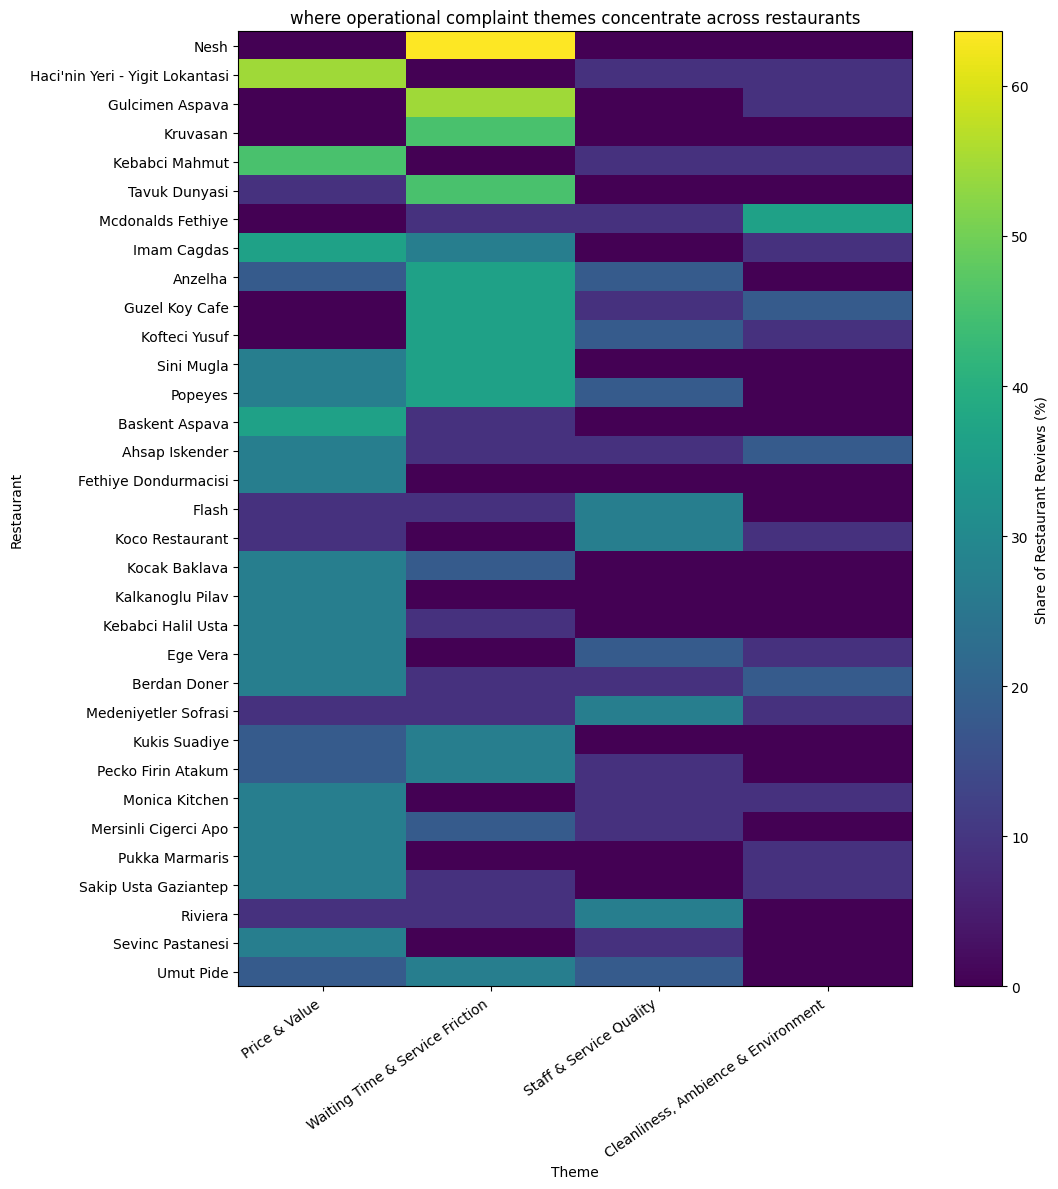

In [237]:
plt.figure(figsize=(11, 12))
plt.imshow(operational_heatmap,aspect='auto')
plt.colorbar( label='Share of Restaurant Reviews (%)')
plt.xticks(range(len(operational_heatmap.columns)), operational_heatmap.columns,rotation=35, ha='right')

plt.yticks(range(len(operational_heatmap.index)),operational_heatmap.index)
plt.title('where operational complaint themes concentrate across restaurants')
plt.xlabel('Theme')
plt.ylabel('Restaurant')

plt.tight_layout()
plt.show()

### Cross-Restaurant Pattern

The heatmap demonstrates that operational complaint themes are not evenly distributed among restaurants; some are closely linked to a single, predominant issue, such as cleanliness, waiting times, or prices, while others exhibit a more evenly distributed range of issues.

This implies that some complaint themes might represent operational issues unique to restaurants rather than problems that affect the entire industry. Nevertheless, the percentages should be interpreted in conjunction with the underlying review counts rather than as exact population estimates because each restaurant has only 11 reviews.

## **10. Cross-Restaurant Theme Comparison**

In order to determine whether the final themes were widely dispersed or concentrated at specific locations, they were compared across restaurants.There are only 11 reviews for each restaurant in the dataset, so restaurant-level percentages need to be interpreted carefully. A single review makes up about 9.1% of a restaurant's available sample. Because of this, percentages and raw review counts are both provided.

Smaller counts are considered limited evidence, whereas operational themes with at least three supporting reviews at a restaurant are considered stronger evidence.

## **11. Restaurant-Type Comparison**

The client was especially curious about whether different restaurant types had different complaint themes.

Since there is no explicit restaurant-type field in the dataset, restaurant type is only inferred conservatively when the business name includes a clear type indicator, like 'Pizza,' 'Burger,' 'Cafe,' or 'Kebab.' Restaurants classified as 'Other / Unknown' are those whose type cannot be reliably determined from their name.

This derived field is not regarded as verified restaurant metadata and is only utilized for exploratory comparison.

In [238]:
def derive_restaurant_type(name):
    name = str(name).lower()

    if any(word in name for word in ['pizza','pizzeria' ]):
        return 'Pizza'

    if any(word in name for word in ['burger','burber']):
        return 'Burger'

    if 'cafe' in name:
        return 'Cafe'

    if any(word in name for word in [ 'kebab', 'kebabci']):
        return 'Kebab'

    if any(word in name for word in ['dondurma','dondurmacisi']):
        return 'Dessert / Ice Cream'

    if any(word in name for word in ['pastanesi','firin', 'baklava']):
        return 'Bakery / Dessert'

    if any(word in name for word in ['lokantasi','lokantası']):
        return 'Local Restaurant'

    if 'restaurant' in name:
        return 'Restaurant'

    return 'Other / Unknown'
model_df['restaurant_type'] = (
    model_df['business_name']
    .apply(derive_restaurant_type)
)

In [239]:
restaurant_type_summary = (
    model_df[
        ['business_name', 'restaurant_type']
    ]
    .drop_duplicates()
    ['restaurant_type']
    .value_counts()
)

display(
    restaurant_type_summary
    .to_frame('restaurants')
)

,restaurants
restaurant_type,
Other / Unknown,70
Restaurant,8
Local Restaurant,5
Pizza,4
Bakery / Dessert,4
Cafe,3
Burger,3
Kebab,2
Dessert / Ice Cream,1


In [240]:
restaurant_type_mapping = ( model_df[['business_name', 'restaurant_type']].drop_duplicates().sort_values(
    ['restaurant_type', 'business_name']))
display(restaurant_type_mapping)

,business_name,restaurant_type
297,Alsancak Firin,Bakery / Dessert
946,Kocak Baklava,Bakery / Dessert
407,Pecko Firin Atakum,Bakery / Dessert
649,Sevinc Pastanesi,Bakery / Dessert
1001,J Burber,Burger
...,...,...
935,Fikret Balik Restaurant,Restaurant
880,Inegol Restaurant,Restaurant
528,Kasikla Restaurant,Restaurant
803,Koco Restaurant,Restaurant


**11.2 Theme distribution by restaurant type**

In [241]:
type_theme_counts = pd.crosstab(model_df['restaurant_type'],model_df['theme'])
type_theme_percent = (type_theme_counts.div( type_theme_counts.sum(axis=1),axis=0) * 100)
display(type_theme_percent.round(1))

theme,Burger Experience,"Cleanliness, Ambience & Environment",Food Taste & Satisfaction,Overall Dining Experience & Menu Variety,Pizza Experience,Positive Overall Experience,Price & Value,Regional / Specialty Food Experience,Short Positive Praise / Recommendation,Staff & Service Quality,Waiting Time & Service Friction
restaurant_type,,,,,,,,,,,
Bakery / Dessert,0.0,0.0,22.7,13.6,0.0,9.1,22.7,13.6,2.3,4.5,11.4
Burger,48.5,3.0,0.0,9.1,0.0,6.1,12.1,6.1,3.0,6.1,6.1
Cafe,3.0,9.1,3.0,12.1,12.1,21.2,0.0,6.1,9.1,6.1,18.2
Dessert / Ice Cream,0.0,0.0,36.4,0.0,0.0,9.1,27.3,9.1,18.2,0.0,0.0
Kebab,4.5,4.5,13.6,9.1,0.0,9.1,36.4,13.6,0.0,4.5,4.5
Local Restaurant,0.0,7.3,1.8,21.8,0.0,10.9,14.5,21.8,9.1,7.3,5.5
Other / Unknown,5.5,6.4,7.8,16.1,0.8,14.7,11.4,11.0,7.0,7.7,11.7
Pizza,0.0,2.3,2.3,2.3,72.7,9.1,0.0,0.0,0.0,2.3,9.1
Restaurant,6.8,8.0,6.8,26.1,0.0,15.9,8.0,5.7,5.7,8.0,9.1


In [242]:
type_operational_percent = (type_theme_percent[ operational_themes])
display(type_operational_percent.round(1))

theme,Price & Value,Waiting Time & Service Friction,Staff & Service Quality,"Cleanliness, Ambience & Environment"
restaurant_type,,,,
Bakery / Dessert,22.7,11.4,4.5,0.0
Burger,12.1,6.1,6.1,3.0
Cafe,0.0,18.2,6.1,9.1
Dessert / Ice Cream,27.3,0.0,0.0,0.0
Kebab,36.4,4.5,4.5,4.5
Local Restaurant,14.5,5.5,7.3,7.3
Other / Unknown,11.4,11.7,7.7,6.4
Pizza,0.0,9.1,2.3,2.3
Restaurant,8.0,9.1,8.0,8.0


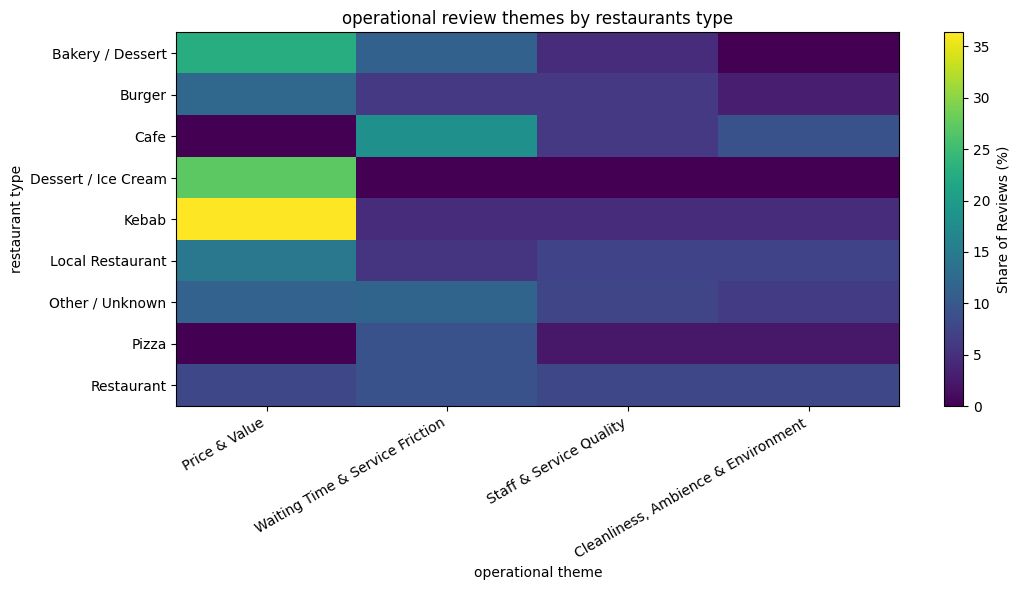

In [243]:
plt.figure(figsize=(11, 6))
plt.imshow(type_operational_percent,aspect='auto')
plt.colorbar(label='Share of Reviews (%)')

plt.xticks(range( len(type_operational_percent.columns)),type_operational_percent.columns,rotation=30,ha='right')

plt.yticks(range(len(type_operational_percent.index)),type_operational_percent.index)
plt.xlabel('operational theme')
plt.ylabel('restaurant type')
plt.title('operational review themes by restaurants type')

plt.tight_layout()
plt.show()

**Make the comparison more trustworthy**

In [244]:
type_support = (
    model_df.groupby('restaurant_type').agg(reviews=('text_original', 'count'),restaurants=('business_name', 'nunique'),average_rating=('rating', 'mean') ).sort_values('reviews',ascending=False).round(2))
display(type_support)

,reviews,restaurants,average_rating
restaurant_type,,,
Other / Unknown,770,70,3.91
Restaurant,88,8,3.78
Local Restaurant,55,5,4.09
Bakery / Dessert,44,4,3.82
Pizza,44,4,4.05
Cafe,33,3,4.12
Burger,33,3,3.73
Kebab,22,2,4.09
Dessert / Ice Cream,11,1,3.91


## **12. Supported Restaurant Type Comparison&**

The dataset does not directly provide the type of restaurant. Only when the company name included a clear indicator, like 'Pizza,' 'Cafe,' or 'Burger,' was a conservative type derived. Restaurant-type comparisons are regarded as exploratory rather than definitive since many restaurants cannot be categorized with confidence.

Only restaurant types represented by at least three restaurants are kept, and `Other / Unknown` is eliminated to minimize erratic comparisons.

In [245]:
type_restaurant_counts = (
    model_df[ ['business_name', 'restaurant_type']].drop_duplicates()['restaurant_type'].value_counts())
supported_types = type_restaurant_counts[type_restaurant_counts >= 3].index.tolist()
supported_types = [
    restaurant_type
    for restaurant_type in supported_types
    if restaurant_type != 'Other / Unknown']
print('Supported restaurant types:')
print(supported_types)

Supported restaurant types:
['Restaurant', 'Local Restaurant', 'Pizza', 'Bakery / Dessert', 'Cafe', 'Burger']


In [246]:
type_analysis_df = model_df[model_df['restaurant_type'].isin(supported_types)].copy()
print('Reviews included:',len(type_analysis_df))
print('Restaurants included:',type_analysis_df['business_name'].nunique())

Reviews included: 297
Restaurants included: 27


**12.2 Build the supported operational-theme table**

In [247]:
supported_type_theme_counts = pd.crosstab(type_analysis_df['restaurant_type'],type_analysis_df['theme'])
supported_type_theme_percent = (supported_type_theme_counts.div(supported_type_theme_counts.sum(axis=1), axis=0)* 100)
supported_operational = (supported_type_theme_percent[operational_themes].round(1))
display(supported_operational)

theme,Price & Value,Waiting Time & Service Friction,Staff & Service Quality,"Cleanliness, Ambience & Environment"
restaurant_type,,,,
Bakery / Dessert,22.7,11.4,4.5,0.0
Burger,12.1,6.1,6.1,3.0
Cafe,0.0,18.2,6.1,9.1
Local Restaurant,14.5,5.5,7.3,7.3
Pizza,0.0,9.1,2.3,2.3
Restaurant,8.0,9.1,8.0,8.0


In [248]:
supported_type_summary = (type_analysis_df.groupby('restaurant_type').agg(restaurants=('business_name', 'nunique'),reviews=('text_original', 'count'),average_rating=('rating', 'mean')).round(2).sort_values('restaurants',ascending=False))
display(supported_type_summary)

,restaurants,reviews,average_rating
restaurant_type,,,
Restaurant,8,88,3.78
Local Restaurant,5,55,4.09
Pizza,4,44,4.05
Bakery / Dessert,4,44,3.82
Burger,3,33,3.73
Cafe,3,33,4.12


**12.3 Make a better heatmap**

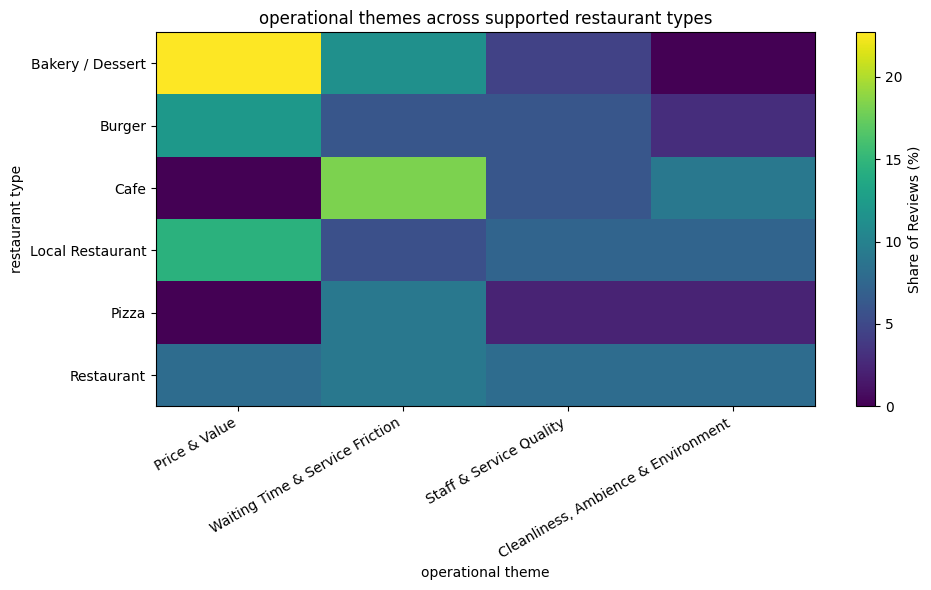

In [249]:
plt.figure(figsize=(10, 6))
plt.imshow(supported_operational, aspect='auto')
plt.colorbar(label='Share of Reviews (%)')
plt.xticks(range(len(supported_operational.columns)),supported_operational.columns,rotation=30,ha='right')
plt.yticks( range(len(supported_operational.index)),supported_operational.index)
plt.xlabel('operational theme')
plt.ylabel('restaurant type')
plt.title('operational themes across supported restaurant types')
plt.tight_layout()
plt.show()

**12.4 Calculate how unusual each type is**

In [250]:
platform_theme_percent = ( model_df['theme'].value_counts(normalize=True).mul(100))

platform_operational = (platform_theme_percent[operational_themes])
display(platform_operational.round(1).to_frame('platform_percent'))

,platform_percent
theme,
Price & Value,11.6
Waiting Time & Service Friction,10.8
Staff & Service Quality,7.1
"Cleanliness, Ambience & Environment",6.0


In [251]:
type_theme_lift = (supported_operational.subtract( platform_operational,axis='columns'))
display( type_theme_lift.round(1))

theme,Price & Value,Waiting Time & Service Friction,Staff & Service Quality,"Cleanliness, Ambience & Environment"
restaurant_type,,,,
Bakery / Dessert,11.1,0.6,-2.6,-6.0
Burger,0.5,-4.7,-1.0,-3.0
Cafe,-11.6,7.4,-1.0,3.1
Local Restaurant,2.9,-5.3,0.2,1.3
Pizza,-11.6,-1.7,-4.8,-3.7
Restaurant,-3.6,-1.7,0.9,2.0


**12.5 Visualize the lift**

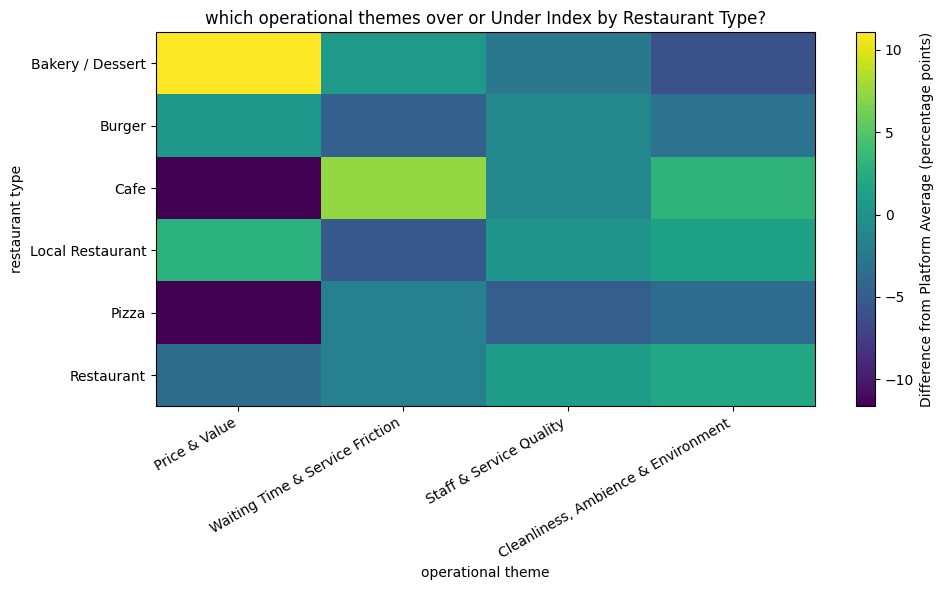

In [252]:
plt.figure(figsize=(10, 6))

plt.imshow( type_theme_lift,aspect='auto')
plt.colorbar(label='Difference from Platform Average (percentage points)')
plt.xticks(range(len(type_theme_lift.columns)), type_theme_lift.columns, rotation=30,ha='right')

plt.yticks( range(len(type_theme_lift.index)),type_theme_lift.index)
plt.xlabel('operational theme')
plt.ylabel('restaurant type')
plt.title('which operational themes over or Under Index by Restaurant Type?')

plt.tight_layout()
plt.show()

**12.6 Automatically extract the strongest deviations**

In [253]:
type_lift_long = (type_theme_lift.reset_index().melt( id_vars='restaurant_type',var_name='theme',value_name='lift_percentage_points'))

type_lift_long[ 'absolute_lift'
] = ( type_lift_long['lift_percentage_points'].abs())

strongest_type_patterns = (type_lift_long.sort_values('absolute_lift',ascending=False).head(10))

display(strongest_type_patterns[ [ 'restaurant_type', 'theme','lift_percentage_points']].round(1))

,restaurant_type,theme,lift_percentage_points
2,Cafe,Price & Value,-11.6
4,Pizza,Price & Value,-11.6
0,Bakery / Dessert,Price & Value,11.1
8,Cafe,Waiting Time & Service Friction,7.4
18,Bakery / Dessert,"Cleanliness, Ambience & Environment",-6.0
9,Local Restaurant,Waiting Time & Service Friction,-5.3
16,Pizza,Staff & Service Quality,-4.8
7,Burger,Waiting Time & Service Friction,-4.7
22,Pizza,"Cleanliness, Ambience & Environment",-3.7
5,Restaurant,Price & Value,-3.6


## **13. Stakeholder Findings**

Price, waiting time and service friction, service quality, and cleanliness/ambience are some of the operational themes that are common to all restaurants, according to the final analysis. Because only 27 restaurants could be categorized into supported types with at least three restaurants per category, restaurant type comparisons were treated as exploratory. 
### Finding 1 - Waiting-time issues are widespread, but especially elevated in cafés

About 10.8% of reviews on the platform were related to waiting time and service friction. Cafés had the highest rate of any supported restaurant type (18.2%), 7.4 percentage points higher than the platform baseline.
This implies that for cafés in the sample that is currently available, waiting times, responsiveness, or service flow might be particularly significant operational concerns.

### Finding 2 - Bakery and dessert businesses show stronger price/value concerns

Approximately 11.6% of reviews on the entire platform were related to price and value. The rate for bakeries and dessert shops was 22.7%, which is about 11.1 percentage points higher than the platform baseline. Customers may be especially sensitive to perceived value in bakery and dessert contexts, as indicated by the largest positive deviation found among the supported restaurant types.
### Finding 3 - Complaint themes can also concentrate at individual restaurants

Certain themes were highly concentrated at particular businesses, according to the restaurant level analysis. For instance, Nesh received seven out of eleven reviews related to Waiting Time & Service Friction, whereas Haci'nin Yeri Yigit Lokantasi received six out of eleven reviews related to Price & Value. These findings imply that certain operational issues might be unique to restaurants rather than the industry as a whole.

### Finding 4 - Semantic clustering produced both operational and cuisine-specific structure

Both broad operational themes and cuisine-specific groups like Pizza Experience and Burger Experience were found by the final clustering model.
This suggests that the review text has a deeper structure than just positive and negative sentiments. The model was able to distinguish between the type of food experience that patrons were talking about and how they felt about the restaurant.

### Finding 5 - Findings should be used as outreach signals, not definitive restaurant rankings

Since there are only 11 reviews for each restaurant, one review makes up roughly 9.1% of the sample that is available. Therefore, based on just one or two reviews, restaurant level percentages can vary significantly. Rather than being definitive indicators of restaurant performance, the results are best understood as signals that can assist the outreach team in determining where additional research or discussion may be helpful.

## **14. Assumptions Log**

The analysis relies on several assumptions that affect how the results should be interpreted:-

| Assumption | Reason | Potential Impact |
|---|---|---|
| All 1,100 reviews are included in theme discovery | The client requested analysis of all reviews rather than only negative ones | Positive and negative experiences may appear within the same semantic theme |
| Ratings are used only for interpretation, not clustering | The goal is to discover themes naturally from review text | Clusters may contain mixed sentiment |
| Repeated short reviews such as 'Great' or 'Expensive' are retained | They occur across different restaurants and may represent genuine independent reviews | Very short expressions may influence some clusters |
| Restaurant-level percentages are based on 11 reviews per restaurant | The dataset contains exactly 11 reviews for each restaurant | One review changes a restaurant-level percentage by about 9.1 percentage points |
| Restaurant type is derived conservatively from business names | The dataset does not provide verified restaurant-type metadata | Restaurant-type findings are exploratory and may not cover all businesses accurately |
| Only restaurant types represented by at least three restaurants are compared | Very small groups would produce unstable percentages | Some potentially interesting types are excluded |
| Cluster labels are assigned through human interpretation | Unsupervised models do not generate stakeholder-ready labels automatically | Theme naming involves judgment |
| Semantic similarity is treated as evidence of thematic similarity | Sentence embeddings encode overall meaning | Reviews discussing multiple issues may still be assigned to one dominant cluster |

**These assumptions were documented before drawing stakeholder conclusions so that model outputs are not interpreted as stronger evidence than the dataset supports.**

## **15. Limitations**

### Small restaurant-level samples

Restaurant level percentages can vary significantly based on just one or two reviews because each restaurant has only 11 reviews. Therefore, rather than being exact indicators of restaurant performance, the concentrations found should be regarded as early warning signs.

### Restaurant-type metadata

There isn't a verified restaurant-type field in the dataset. Many restaurants were left unclassified because restaurant types were conservatively derived from obvious business name indicators. Therefore, restaurant type comparisons should be considered exploratory as they only cover a portion of the dataset.

### Multi-topic reviews

The final K-Means model assigns each review to a single cluster, so secondary themes within the same review may not be represented. However, a single review can address multiple issues at once, such as food quality, waiting time, price, and staff behaviour.

### Human interpretation of clusters

Groups of reviews that are semantically similar are found by the clustering model, but their business meaning is not automatically ascertained. After examining representative reviews, keywords, rating trends, and restaurant coverage, final theme names were chosen.

### Cluster quality

Silhouette scores were still comparatively low, but the semantic K-Means model outperformed the TF-IDF baseline. This shows theme overlap, which is to be expected given that dining out frequently involves related aspects like food, service, cost, and ambiance.

### Density-based clustering trade-off

Although UMAP + HDBSCAN generated many small clusters and identified a significant percentage of reviews as noise, it also produced some highly specific complaint groups and stronger numerical separation. Because of this, it was not used as the final model but instead kept as a supporting experiment.

### Dataset representativeness

The dataset may not accurately reflect Turkey's entire restaurant industry because it only includes reviews for a small sample of eateries. Without more proof, conclusions shouldn't be extrapolated from the data at hand.

## **16. Executive Summary**

This project examined 1,100 restaurant reviews from 100 restaurants in order to find recurrent themes related to the customer experience and ascertain whether certain problems are common to all restaurants or are specific to certain types of businesses and restaurants. SentenceTransformer embeddings were used to compare semantic clustering with a baseline of TF-IDF + K-Means. SentenceTransformer embeddings with K-Means were chosen as the final model because the semantic approach generated more cohesive and useful themes.

The final analysis identified 11 themes, including four especially relevant operational themes: **Price & Value**, **Waiting Time & Service Friction**, **Staff & Service Quality**, and **Cleanliness, Ambience & Environment**.

There were a few distinct patterns. In the exploratory restaurant-type comparison, Price & Value appeared in 67% of restaurants, while Waiting Time & Service Friction appeared in 66% of restaurants and was strongly concentrated at some individual businesses. While bakery and dessert businesses showed significantly more price/value discussion, cafes showed more waiting/service-friction discussion than the platform average.

The findings imply that there is an uneven distribution of customer complaints among different types of restaurants. As a result, the outreach team can use the themes as indicators to pinpoint areas where particular operational problems might need more research or focused messaging. These results should be regarded as exploratory decision support signals rather than final assessments of restaurant performance because each restaurant only has 11 reviews and restaurant-type metadata is lacking.

## **17. Conclusion**

The analysis shows that unsupervised semantic clustering can convert unprocessed restaurant reviews into comprehensible themes that are more valuable than just ratings. Price/value, waiting time, staff/service quality, cleanliness or environment were the strongest operational patterns. While some themes were heavily concentrated at specific establishments, others were prevalent throughout restaurants. Additionally, the project demonstrated the significance of model comparison. Semantic embeddings enhanced thematic coherence, TF-IDF offered a transparent baseline, and HDBSCAN identified niche patterns but added significant fragmentation and noise.

All things considered, the final semantic K-Means model offered the best compromise between stakeholder utility, interpretability, and review coverage.

In [257]:
streamlit_export = model_df[ ["business_name","text_original","rating", "rating_category","rating_group", "review_word_count", "final_cluster", "theme", "theme_confidence","restaurant_type",]
].copy()
streamlit_export.to_csv("serafino_reviews.csv",index=False,)
print("Saved:", streamlit_export.shape)
display(streamlit_export.head())

Saved: (1100, 10)


,business_name,text_original,rating,rating_category,rating_group,review_word_count,final_cluster,theme,theme_confidence,restaurant_type
0,Haci'nin Yeri - Yigit Lokantasi,We went to Marmaris with my wife for a holiday. We chose this restaurant as a place for dinner based on the reviews and because we wanted juicy fo...,5,taste,POSITIVE (4-5),130,2,Overall Dining Experience & Menu Variety,Medium,Local Restaurant
1,Haci'nin Yeri - Yigit Lokantasi,During my holiday in Marmaris we ate here to fit the food. It's really good that the food is cheap and nice. Eating as much bread as you want is a...,4,menu,POSITIVE (4-5),179,3,Price & Value,High,Local Restaurant
2,Haci'nin Yeri - Yigit Lokantasi,Prices are very affordable. The menu in the photo cost 108 liras. You have to wait 10-15 minutes for food. Staff is annoying. Well it tastes good....,3,outdoor_atmosphere,MIXED (3),31,3,Price & Value,High,Local Restaurant
3,Haci'nin Yeri - Yigit Lokantasi,Turkey's cheapest artisan restaurant and its food is delicious!,5,indoor_atmosphere,POSITIVE (4-5),9,1,Regional / Specialty Food Experience,Medium,Local Restaurant
4,Haci'nin Yeri - Yigit Lokantasi,I don't know what you will look for in terms of price performance point; taste; but yigit restaurant writes a big plus for those who come to work ...,3,menu,MIXED (3),31,3,Price & Value,High,Local Restaurant


**Links-** 

Presentation - https://drive.google.com/drive/u/0/folders/1crF_Tod-MzpZwBCCUmAk3YGkgJXltjlR


StreamLit- https://data-science-for-human-centered-systems-serafinosignal.streamlit.app/